In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 
import seaborn as sns
import math

import scipy.stats as stats
from scipy.stats import gaussian_kde
from scipy.signal import argrelextrema

from scipy.sparse import issparse

import gc


# set figure size for better visibility
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

In [2]:
## --- LOAD DATA ---
adata = sc.read_h5ad("../data/data_filtered_raw.h5ad")

## STANDARD NORMALIZATION

We start with a standard log(x+1) normalization (CPM) to apply the PCA.

In [3]:
'''
# Standar normalization (CPM - Counts Per Million)
sc.pp.normalize_total(adata, target_sum=1e4)

# Logarithmic transformation (Basic variance stabilization)
sc.pp.log1p(adata)

# Save normalized mixed data
adata.write("../data/data_standard_norm_mixed.h5ad", compression="gzip")

## --- Divide data ---
adata_gld = adata[adata.obs['experiment'] == 'gld'].copy()
adata_lncRNA = adata[adata.obs['experiment'] != 'gld'].copy()

# Save separate lncRNA and GLD data 
adata_gld.write("../data/data_standard_norm_gld.h5ad", compression="gzip")
adata_lncRNA.write("../data/data_standard_norm_lncRNA.h5ad", compression="gzip")

'''

'\n# Standar normalization (CPM - Counts Per Million)\nsc.pp.normalize_total(adata, target_sum=1e4)\n\n# Logarithmic transformation (Basic variance stabilization)\nsc.pp.log1p(adata)\n\n# Save normalized mixed data\nadata.write("../data/data_standard_norm_mixed.h5ad", compression="gzip")\n\n## --- Divide data ---\nadata_gld = adata[adata.obs[\'experiment\'] == \'gld\'].copy()\nadata_lncRNA = adata[adata.obs[\'experiment\'] != \'gld\'].copy()\n\n# Save separate lncRNA and GLD data \nadata_gld.write("../data/data_standard_norm_gld.h5ad", compression="gzip")\nadata_lncRNA.write("../data/data_standard_norm_lncRNA.h5ad", compression="gzip")\n\n'

## REFINED NORMALIZATION

We are going implement two major improvements:

1. Traccking the cell cycle genes in order to potentially regressed out them (see histones modification for VASAseq)
2. Only consider the more variable genes + ignore the more abundants 

First an example of how it looks:

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


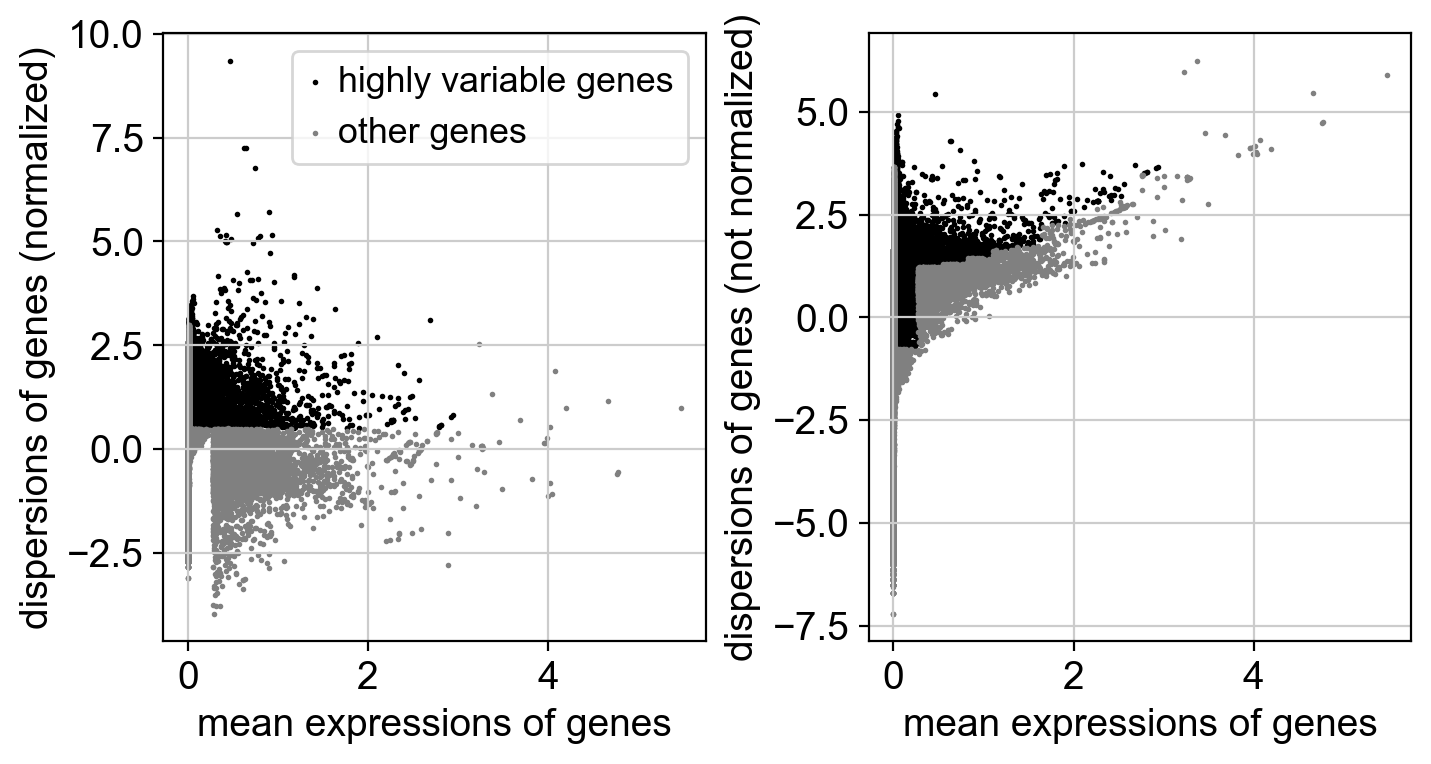

In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Example how selection of variables works
sc.pp.highly_variable_genes(
    adata, 
    min_mean=0.0125, 
    max_mean=3,   # only consider genes with a mean expression between 0.0125 and 3
    min_disp=0.5, # only consider genes with a dispersion (variance/mean) above 0.5
    inplace=True
)

# Plot dispersion diagram (dispersion = variance/mean)
sc.pl.highly_variable_genes(adata)

Now work with the divided data from the beginning: necessary to select the ralative features of each experimental setup

In [ ]:
## --- LOAD DATA ---
adata = sc.read_h5ad("../data/data_filtered_raw.h5ad")

# --- LOAD GENE BIOTYPES ---
# Read annotation and map to adata.var
try:
    gene_annotation = pd.read_csv('../data/gene_biotypes.tsv', sep='\t')
    # Group by gene name to handle duplicates, joining unique biotypes
    gene_annotation = gene_annotation.groupby('gene_name').agg(lambda x: '-'.join(set(x)))
    # Merge into adata.var
    adata.var = adata.var.join(gene_annotation)
except FileNotFoundError:
    print("WARNING: '../data/gene_biotypes.tsv' not found. Biotype filtering will fail.")
    adata.var['gene_biotype'] = 'unknown'

# Create boolean masks for protein coding (useful for later filtering)
adata.var['is_protein_coding'] = adata.var['gene_biotype'] == 'protein_coding'

# Identify histone genes (using prefix matching)
histone_prefixes = ('H1f', 'H2a', 'H2b', 'H3c', 'H3f', 'H4c', 'H4f')
adata.var['is_histone'] = adata.var_names.str.startswith(histone_prefixes)

# Separate experiments 
adata_lncRNA = adata[adata.obs['experiment'] != 'gld'].copy()
adata_gld = adata[adata.obs['experiment'] == 'gld'].copy()

# CPM + Log1p
sc.pp.normalize_total(adata_lncRNA , target_sum=1e4)
sc.pp.log1p(adata_lncRNA)

sc.pp.normalize_total(adata_gld , target_sum=1e4)
sc.pp.log1p(adata_gld)

# ================
# RAW BACKUP
# ================

# Log-normalized, full genome
adata_lncRNA.raw = adata_lncRNA.copy()
adata_gld.raw = adata_gld.copy()

# ==========================================
# FEATURE SELECTION (HVG)
# ==========================================

sc.pp.highly_variable_genes(
    adata_lncRNA, 
    min_mean=0.0125, 
    max_mean=3, 
    min_disp=0.5
)
print(f"HVGs lncRNA (pre-blacklist): {sum(adata_lncRNA.var['highly_variable'])}")

sc.pp.highly_variable_genes(
    adata_gld, 
    min_mean=0.0125, 
    max_mean=3, 
    min_disp=0.5
)
print(f"HVGs gld (pre-blacklist): {sum(adata_gld.var['highly_variable'])}")

# ==========================================
# CELL CYCLE & EXTENDED BLACKLIST
# ==========================================

# A. DEFINE CELL CYCLE GENES MANUALLY (MOUSE FORMAT)
s_genes_mm =[
    'Mcm5', 'Pcna', 'Tyms', 'Fen1', 'Mcm2', 'Mcm4', 'Rrm1', 'Ung', 'Gins2',
    'Mcm6', 'Cdca7', 'Dtl', 'Prim1', 'Uhrf1', 'Mlf1ip', 'Hells', 'Rfc2',
    'Rpa2', 'Nasp', 'Rad51ap1', 'Gmnn', 'Wdr76', 'Slbp', 'Ccne2', 'Ubr7',
    'Pold3', 'Msh2', 'Atad2', 'Rad51', 'Rrm2', 'Cdc45', 'Cdc6', 'Exo1',
    'Tipin', 'Dscc1', 'Blm', 'Casp8ap2', 'Usp1', 'Clspn', 'Pol1', 'Chaf1b',
    'Brip1', 'E2f8'
]

g2m_genes_mm =[
    'Hmgb2', 'Cdk1', 'Nusap1', 'Ube2c', 'Birc5', 'Tpx2', 'Top2a', 'Ndc80',
    'Cks2', 'Nuf2', 'Cks1b', 'Mki67', 'Tmpo', 'Cenpf', 'Tacc3', 'Fam64a',
    'Smc4', 'Ccnb1', 'Ckap2l', 'Ckap2', 'Aurkb', 'Bub1', 'Kif11', 'Anp32e',
    'Tubb4b', 'Gtse1', 'Kif20b', 'Hjurp', 'Cdca3', 'Hn1', 'Cdc20', 'Ttk',
    'Cdc25c', 'Kif2c', 'Rangap1', 'Ncapd2', 'Dlgap5', 'Cdca2', 'Cdca8',
    'Ect2', 'Kif23', 'Hmmr', 'Aurka', 'Psrc1', 'Anln', 'Lbr', 'Ckap5',
    'Cenpe', 'Ctcf', 'Nek2', 'G2e3', 'Gas2l3', 'Cbx5', 'Cenpa'
]

s_genes = [g for g in s_genes_mm if g in adata.var_names]
g2m_genes =[g for g in g2m_genes_mm if g in adata.var_names]

# B. Calculate Cycle Score
sc.tl.score_genes_cell_cycle(adata_gld, s_genes=s_genes, g2m_genes=g2m_genes)
sc.tl.score_genes_cell_cycle(adata_lncRNA, s_genes=s_genes, g2m_genes=g2m_genes)

# C. Define Extended Blacklist
blacklist_cc = s_genes + g2m_genes
ribo_genes = adata.var_names[adata.var_names.str.startswith(('Rps', 'Rpl'))].tolist()
mito_genes = adata.var_names[adata.var_names.str.startswith(('mt-', 'MT-'))].tolist()

# Add histones explicitly
histone_genes_list = adata.var_names[adata.var['is_histone']].tolist()

full_blacklist = set(blacklist_cc + ribo_genes + mito_genes + histone_genes_list)
print(f"Total Blacklisted genes (CC + Ribo + Mito + Histones): {len(full_blacklist)}")

# D. Apply Blacklist (Disable highly_variable flag)
for gene in full_blacklist:
    if gene in adata_lncRNA.var_names:
        adata_lncRNA.var.loc[gene, 'highly_variable'] = False
    if gene in adata_gld.var_names:
        adata_gld.var.loc[gene, 'highly_variable'] = False

print(f"Effective HVGs IN lncRNA: {sum(adata_lncRNA.var['highly_variable'])}")
print(f"Effective HVGs IN gld: {sum(adata_gld.var['highly_variable'])}")

# -------- Subset Matrix (HVG only) --------
adata_hvg_gld = adata_gld[:, adata_gld.var.highly_variable].copy()
adata_hvg_lncRNA = adata_lncRNA[:, adata_lncRNA.var.highly_variable].copy()

normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
HVGs lncRNA (pre-blacklist): 17457
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
HVGs gld (pre-blacklist): 13589
calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    82 total control genes are used. (0:00:00)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    40 total control genes are used. (0:00:00)
-->     'phase', cell cycl

## Without regressing cell cycle

In [6]:
# ==========================================
# Z-SCORE SCALING
# ==========================================

sc.pp.scale(adata_hvg_gld, max_value=10)
sc.pp.scale(adata_hvg_lncRNA, max_value=10)

# Save the normalization with Z-score, feature selection and cell cycle score
adata_hvg_gld.write("../data/data_standard_norm_gld.h5ad", compression="gzip")
adata_hvg_lncRNA.write("../data/data_standard_norm_lncRNA.h5ad", compression="gzip")

/Users/jaime/miniforge3/envs/lncRNA_ASO/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jaime/miniforge3/envs/lncRNA_ASO/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## Regressing out

Eliminate the correlations of the cell cycle  and the rest of gene expression (we only apply it to the HVGs)

NOTE: For VASAseq this method do not work!!! We can use the histones method instead.

In [7]:
'''
## --- ORTHOGONALIZING (REGRESS OUT) ---
sc.pp.regress_out(adata_hvg_gld,['S_score', 'G2M_score'])
sc.pp.regress_out(adata_hvg_lncRNA,['S_score', 'G2M_score'])

# ==========================================
# Z-SCORE SCALING
# ==========================================

sc.pp.scale(adata_hvg_gld, max_value=10)
sc.pp.scale(adata_hvg_lncRNA, max_value=10)

# Save the normalization with Z-score, feature selection and cell cycle score
adata_hvg_gld.write("../data/data_standard_norm_regress_gld_WRONG.h5ad", compression="gzip")
adata_hvg_lncRNA.write("../data/data_standard_norm_regress_lncRNA_WRONG.h5ad", compression="gzip")
'''

'\n## --- ORTHOGONALIZING (REGRESS OUT) ---\nsc.pp.regress_out(adata_hvg_gld,[\'S_score\', \'G2M_score\'])\nsc.pp.regress_out(adata_hvg_lncRNA,[\'S_score\', \'G2M_score\'])\n\n# ==========================================\n# Z-SCORE SCALING\n# ==========================================\n\nsc.pp.scale(adata_hvg_gld, max_value=10)\nsc.pp.scale(adata_hvg_lncRNA, max_value=10)\n\n# Save the normalization with Z-score, feature selection and cell cycle score\nadata_hvg_gld.write("../data/data_standard_norm_regress_gld_WRONG.h5ad", compression="gzip")\nadata_hvg_lncRNA.write("../data/data_standard_norm_regress_lncRNA_WRONG.h5ad", compression="gzip")\n'

## Regressing out using histones

First of all identify histones and check the bimodal distribution in the population. 

Second peak correspond to the cells in phase S (where DNA and histones duplicate). We consider that G2/M phases are less relevant.


--- PROCESSING: lncRNA Dataset (1947 cells) ---
Histone genes found: 101


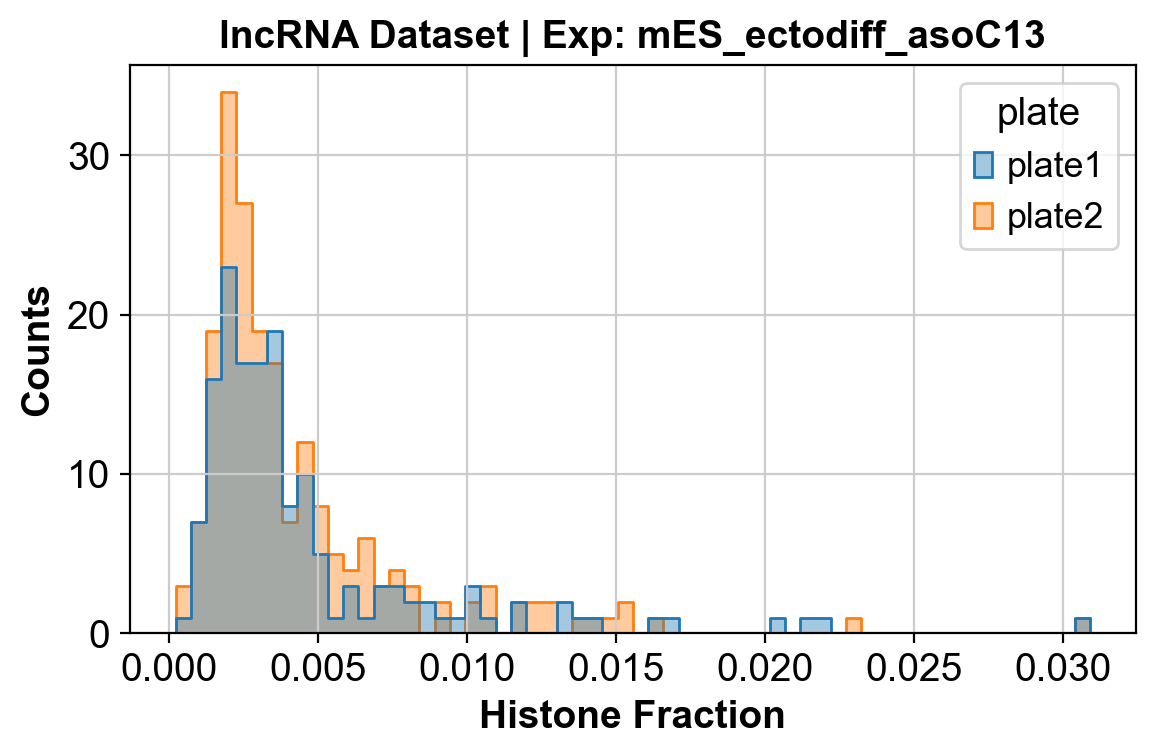

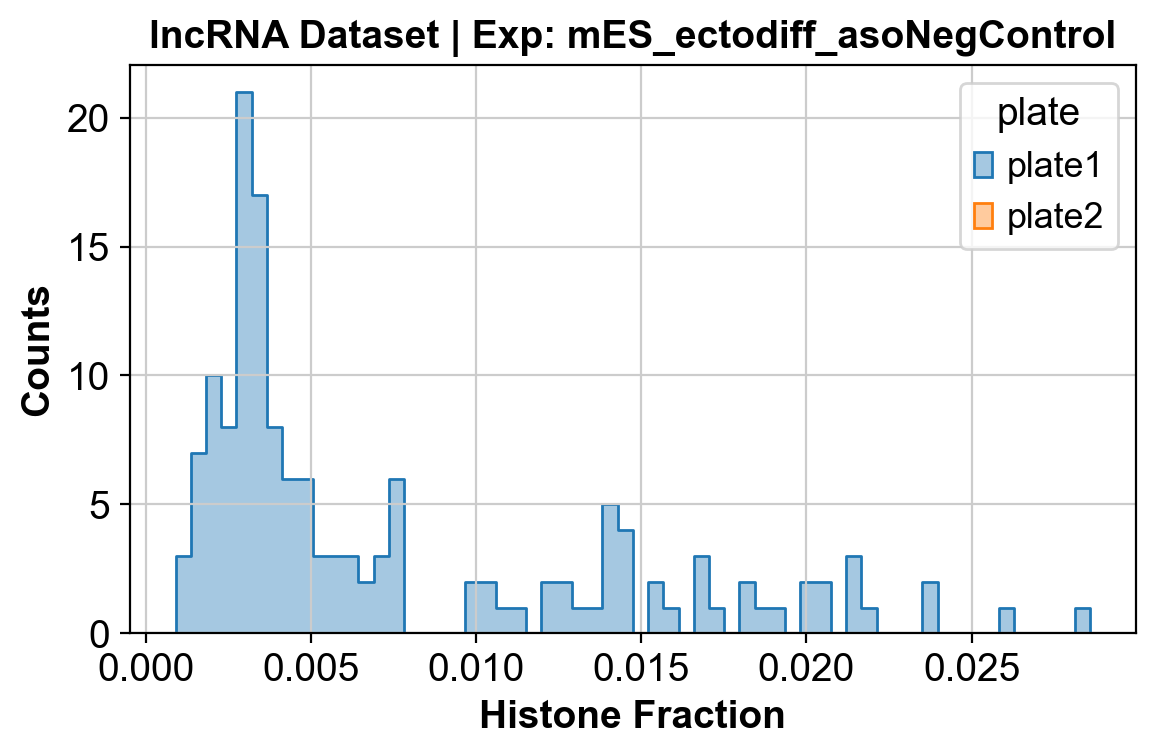

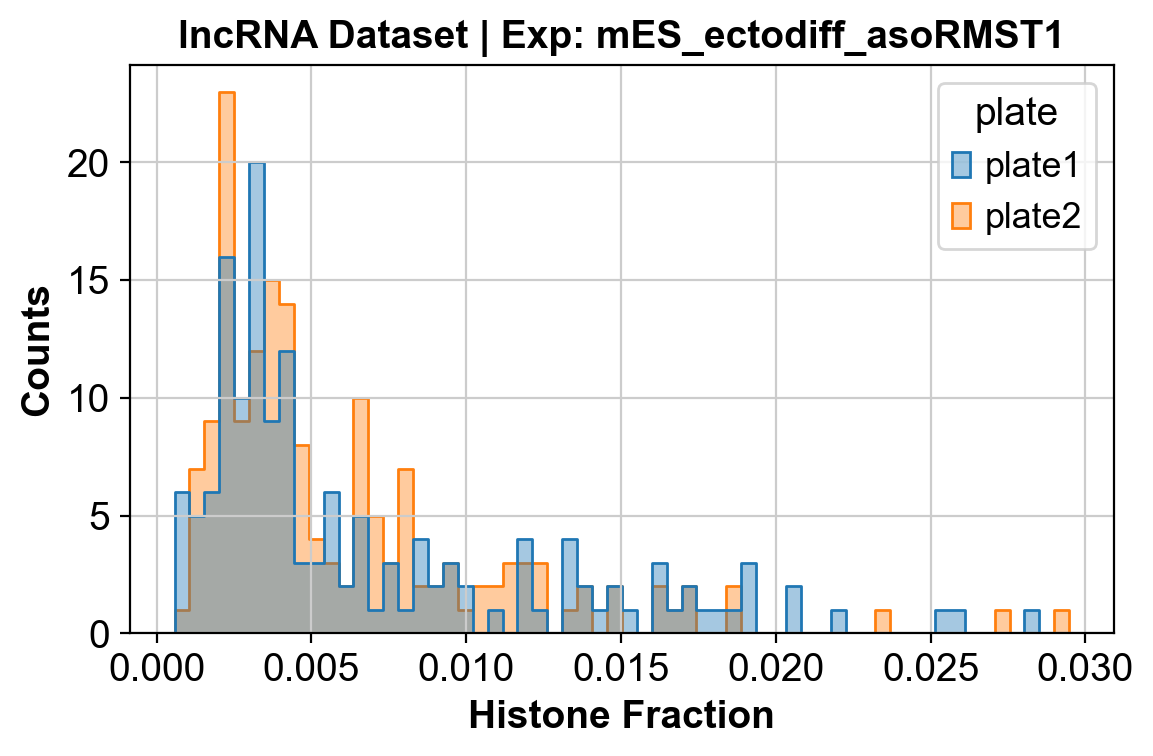

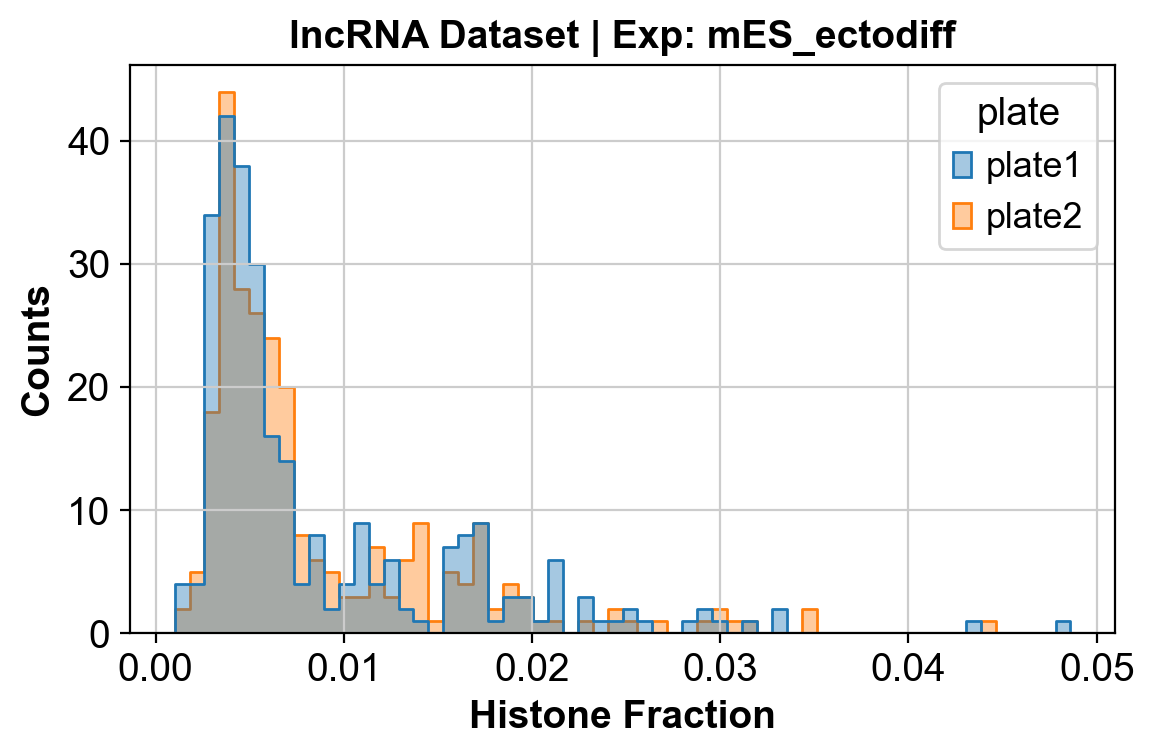

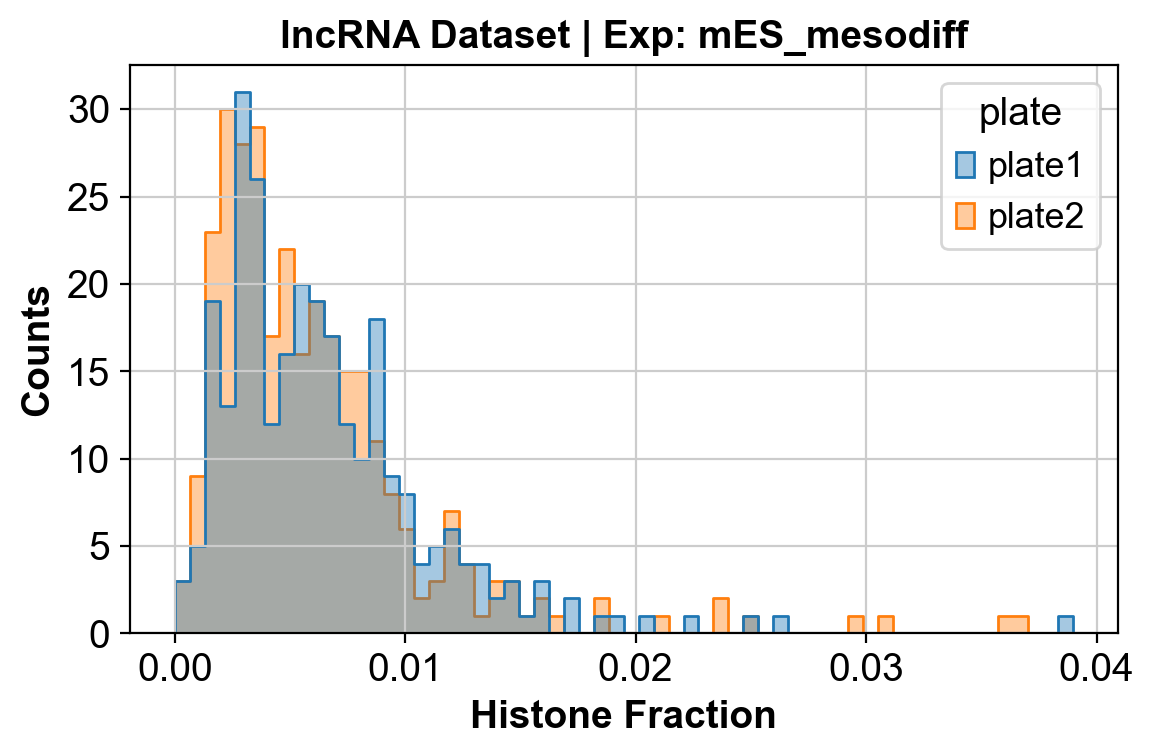


--- PROCESSING: Gastruloids Dataset (1364 cells) ---
Histone genes found: 101


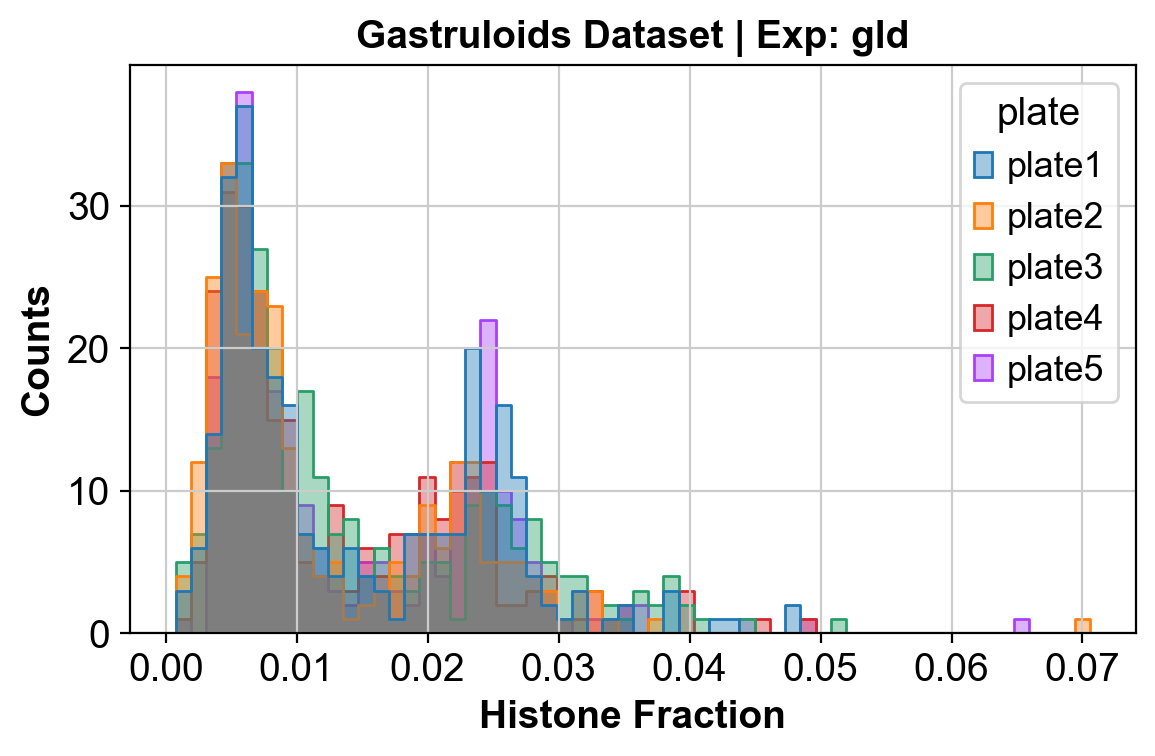

In [8]:
# --- IDENTIFY HISTONE GENES ---

def calculate_and_plot_histones(obj_name, obj):
    """
    Calculates histone fraction and plots the distribution for an AnnData object.
    """
    print(f"\n==================================================")
    print(f"--- PROCESSING: {obj_name} ({obj.n_obs} cells) ---")
    print(f"==================================================")
    
    # 1. Identify histone genes
    histone_prefixes = ('H1f', 'H2a', 'H2b', 'H3c', 'H3f', 'H4c', 'H4f')
    histone_genes = [g for g in obj.var_names if g.startswith(histone_prefixes)]
    print(f"Histone genes found: {len(histone_genes)}")
    
    if len(histone_genes) == 0:
        print("WARNING: No histone genes found in this object!")
        return

    # 2. Extract counts DIRECTLY from the object's active matrix (.X)
    if issparse(obj.X):
        # .A1 is a scipy shortcut for np.array(...).flatten()
        histone_counts = obj[:, histone_genes].X.sum(axis=1).A1
        total_counts = obj.X.sum(axis=1).A1
    else:
        histone_counts = obj[:, histone_genes].X.sum(axis=1)
        total_counts = obj.X.sum(axis=1)

    # avoid division by zero
    total_counts[total_counts == 0] = 1 

    # 3. Save the metric inside the correct object
    obj.obs['histone_fraction'] = histone_counts / total_counts

    # 4. Plot the distribution (Bimodal check)
    experiments = obj.obs['experiment'].unique()
    for exp in experiments:
        subset = obj.obs[obj.obs['experiment'] == exp]
        
        plt.figure(figsize=(6, 4))
        sns.histplot(
            data=subset,
            x='histone_fraction',
            hue='plate',
            element='step',
            bins=60,
            alpha=0.4
        )
        plt.title(f"{obj_name} | Exp: {exp}", fontweight='bold')
        plt.xlabel("Histone Fraction", fontweight='bold')
        plt.ylabel("Counts", fontweight='bold')
        plt.tight_layout()
        plt.show()

# --- RUN ---

calculate_and_plot_histones("lncRNA Dataset", adata_lncRNA)
calculate_and_plot_histones("Gastruloids Dataset", adata_gld)

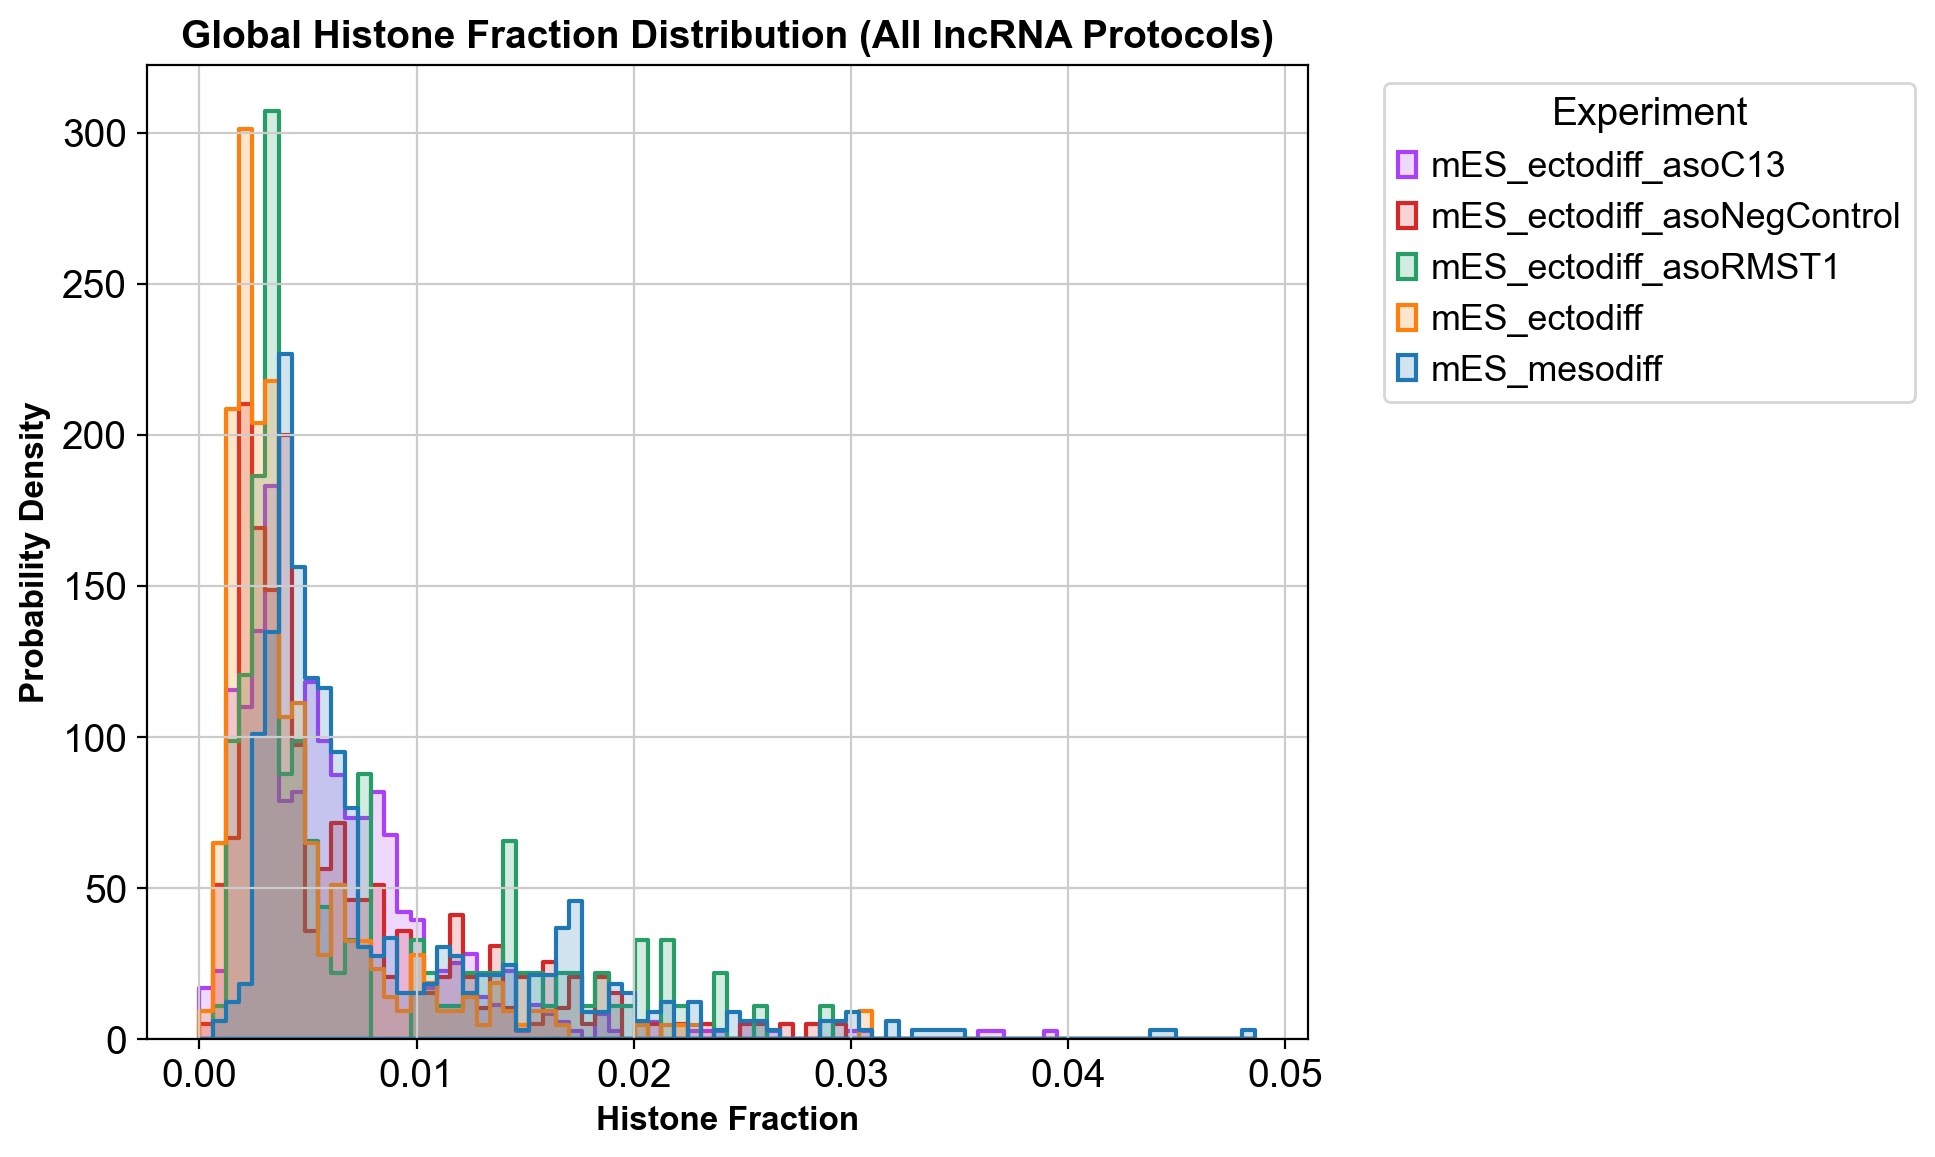

In [9]:
# --- PLOT ALL lncRNA EXPERIMENTS TOGETHER ---

plt.figure(figsize=(10, 6))

# Plot the distribution for the entire lncRNA object
# hue='experiment': Assigns a different color to each protocol
# stat='density': Normalizes the integral of each curve to 1
# common_norm=False: Computes density independently for each experiment
sns.histplot(
    data=adata_lncRNA.obs,
    x='histone_fraction',
    hue='experiment',
    element='step',
    stat='density', 
    common_norm=False, 
    bins=80,
    alpha=0.2,
    linewidth=1.5
)

# Aesthetics and formatting
plt.title("Global Histone Fraction Distribution (All lncRNA Protocols)", fontsize=14, fontweight='bold')
plt.xlabel("Histone Fraction", fontsize=12, fontweight='bold')
plt.ylabel("Probability Density", fontsize=12, fontweight='bold')

# Move legend outside the plot to avoid covering the data
plt.legend(
    title='Experiment', 
    labels=adata_lncRNA.obs['experiment'].unique(),
    bbox_to_anchor=(1.05, 1), 
    loc='upper left'
)

plt.tight_layout()
plt.show()

## SAVE REGRESSION

We then regress out using the histone counts:

We fit a linear model: Gene_expression = Beta * histone_fraction + Residual. We keep ONLY the Residual. This projects the data into a subspace orthogonal to the cell cycle vector.

In [10]:
# Keep ONLY Highly Variable Genes
adata_hvg_gld = adata_gld[:, adata_gld.var.highly_variable].copy()
adata_hvg_lncRNA = adata_lncRNA[:, adata_lncRNA.var.highly_variable].copy()

# Regress out histone fraction
sc.pp.regress_out(adata_hvg_gld, ['histone_fraction'])
sc.pp.regress_out(adata_hvg_lncRNA, ['histone_fraction'])

# Standardize the residuals so every gene has Mean=0 and Variance=1.
# max_value=10 clips extreme outliers to prevent them from dominating the PCA.
sc.pp.scale(adata_hvg_gld, max_value=10)
sc.pp.scale(adata_hvg_lncRNA, max_value=10)

# ----------
#    SAVE   
# ----------

# Save the normalization with Z-score, feature selection and histone regression
adata_hvg_gld.write("../data/data_standard_norm_regress_gld.h5ad", compression="gzip")
adata_hvg_lncRNA.write("../data/data_standard_norm_regress_lncRNA.h5ad", compression="gzip")

regressing out ['histone_fraction']
    sparse input is densified and may lead to high memory use
    finished (0:00:00)
regressing out ['histone_fraction']
    sparse input is densified and may lead to high memory use
    finished (0:00:00)


Verify that histone distribution in UMAP is white noise (no correlation):

computing PCA
    with n_comps=20
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:03)


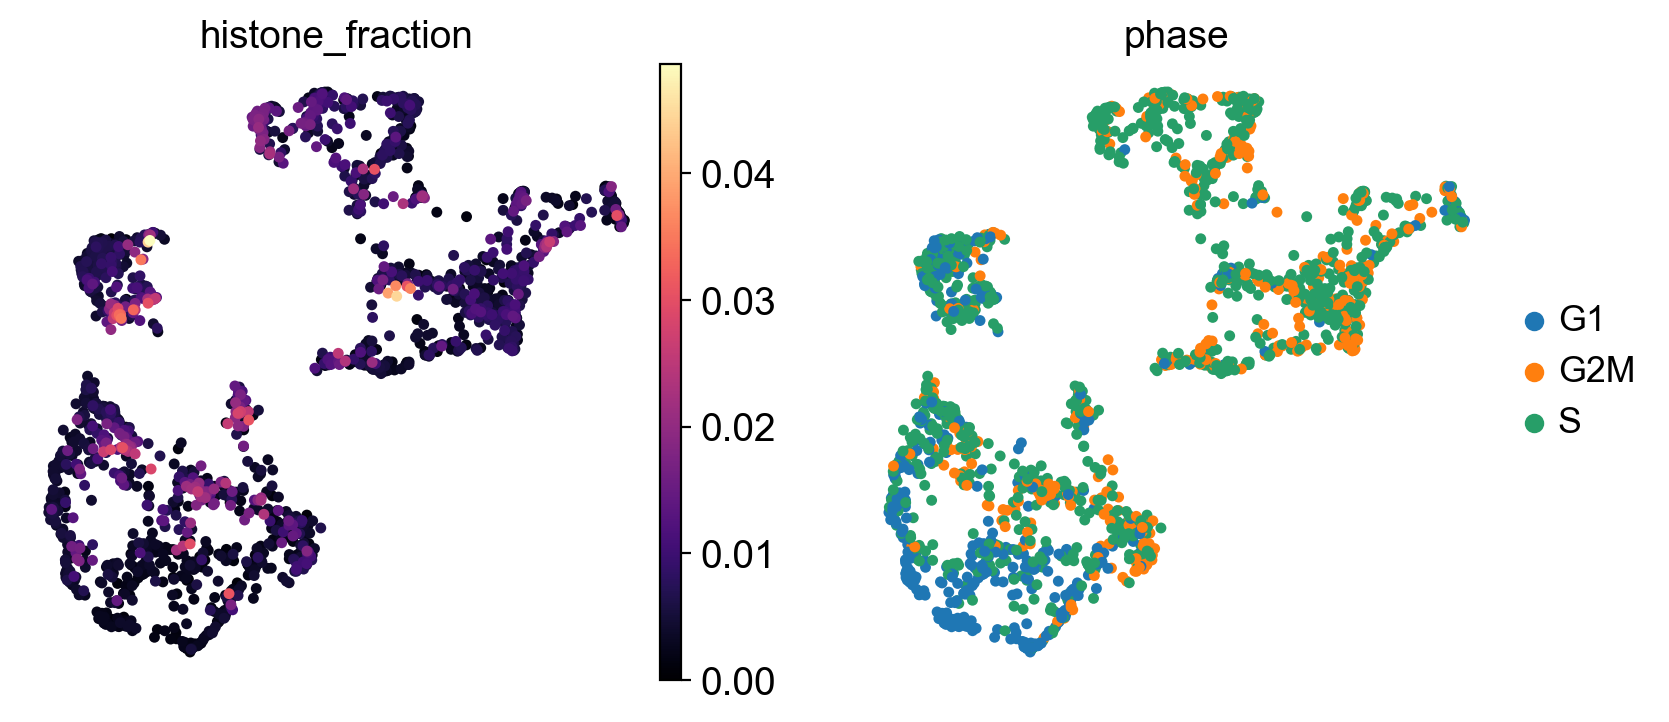


--- Correlation between PCA and Histone Fraction ---
PC1 Correlation: 0.088
PC2 Correlation: -0.020


In [11]:
obj = adata_hvg_lncRNA 
sc.tl.pca(obj, svd_solver='arpack', n_comps=20)
sc.pp.neighbors(obj, n_neighbors=15, n_pcs=20)
sc.tl.umap(obj, random_state=12, min_dist=0.1, spread=0.75)

# --- VISUAL CHECK ---
# Plot 1: Histone fraction on the new UMAP
# Plot 2: Cell cycle phase 

sc.pl.umap(
    obj, 
    color=['histone_fraction', 'phase'], 
    cmap='magma'
)

# --- ANALYTICAL CHECK (PCA CORRELATION) ---

# Extract PC1 and PC2 coordinates
pc1 = obj.obsm['X_pca'][:, 0]
pc2 = obj.obsm['X_pca'][:, 1]
histones = obj.obs['histone_fraction'].values

# Calculate Spearman rank correlation
corr_pc1, pval_pc1 = stats.spearmanr(pc1, histones)
corr_pc2, pval_pc2 = stats.spearmanr(pc2, histones)

print("\n--- Correlation between PCA and Histone Fraction ---")
print(f"PC1 Correlation: {corr_pc1:.3f}")
print(f"PC2 Correlation: {corr_pc2:.3f}")

Correlations are close to 0 (<0.1) so histone fraction is correctly regressed out.

## Distribution ncRNA sequencing depth

VASAseq can inhomogeneously read ncRNA. 

-> we see that reads are pretty much gaussian with same center (except mesoderm)

-> for now no regressing out 

Total genes in raw data: 244105
Protein coding genes: 21709
ALL Non-coding genes (small, lnc, ...): 222396


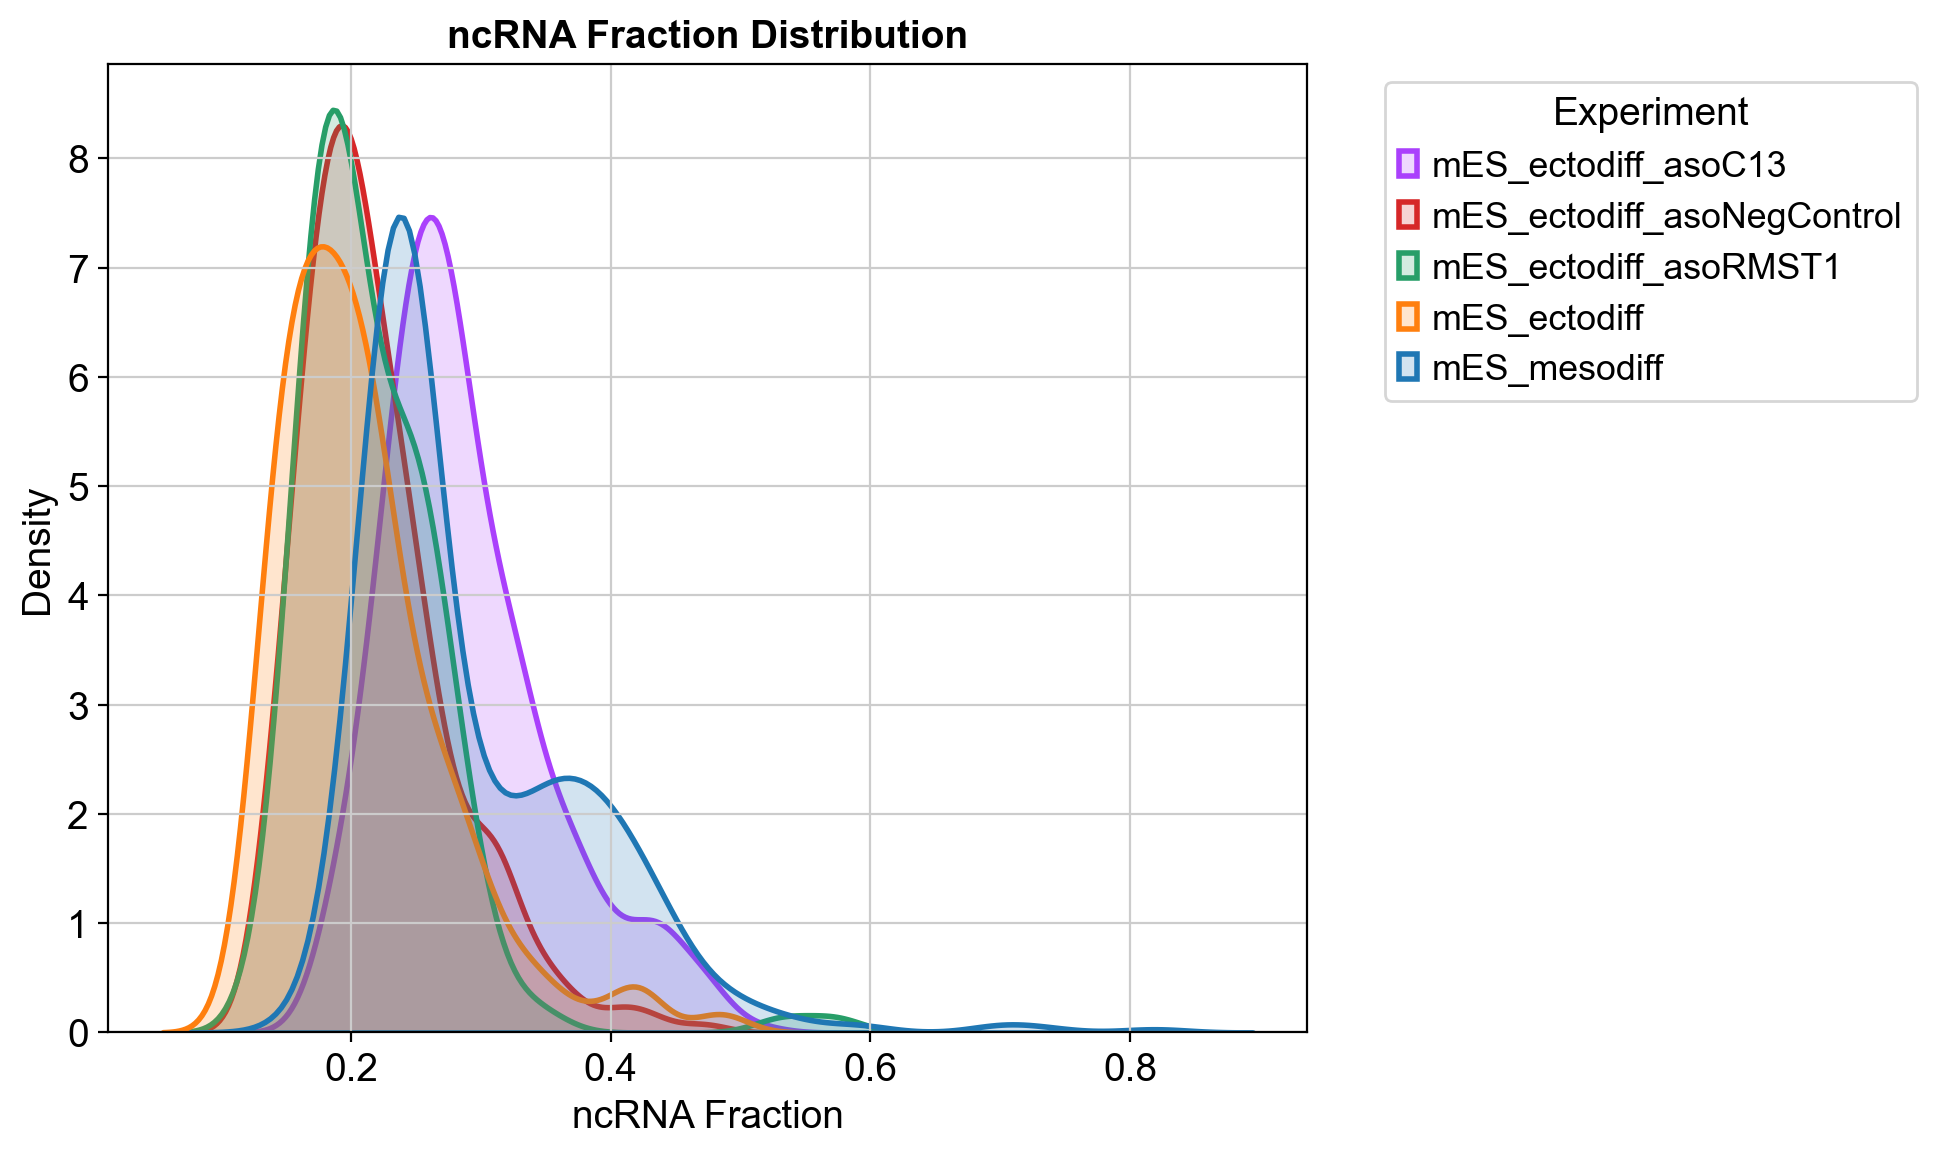

computing PCA
    with n_comps=50
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 19
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden']`


/var/folders/x7/st5qbw1x4w3gr8j8_kcwrvgc0000gn/T/ipykernel_66172/1235467241.py:47: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_lncRNA, resolution=0.4, random_state=12)


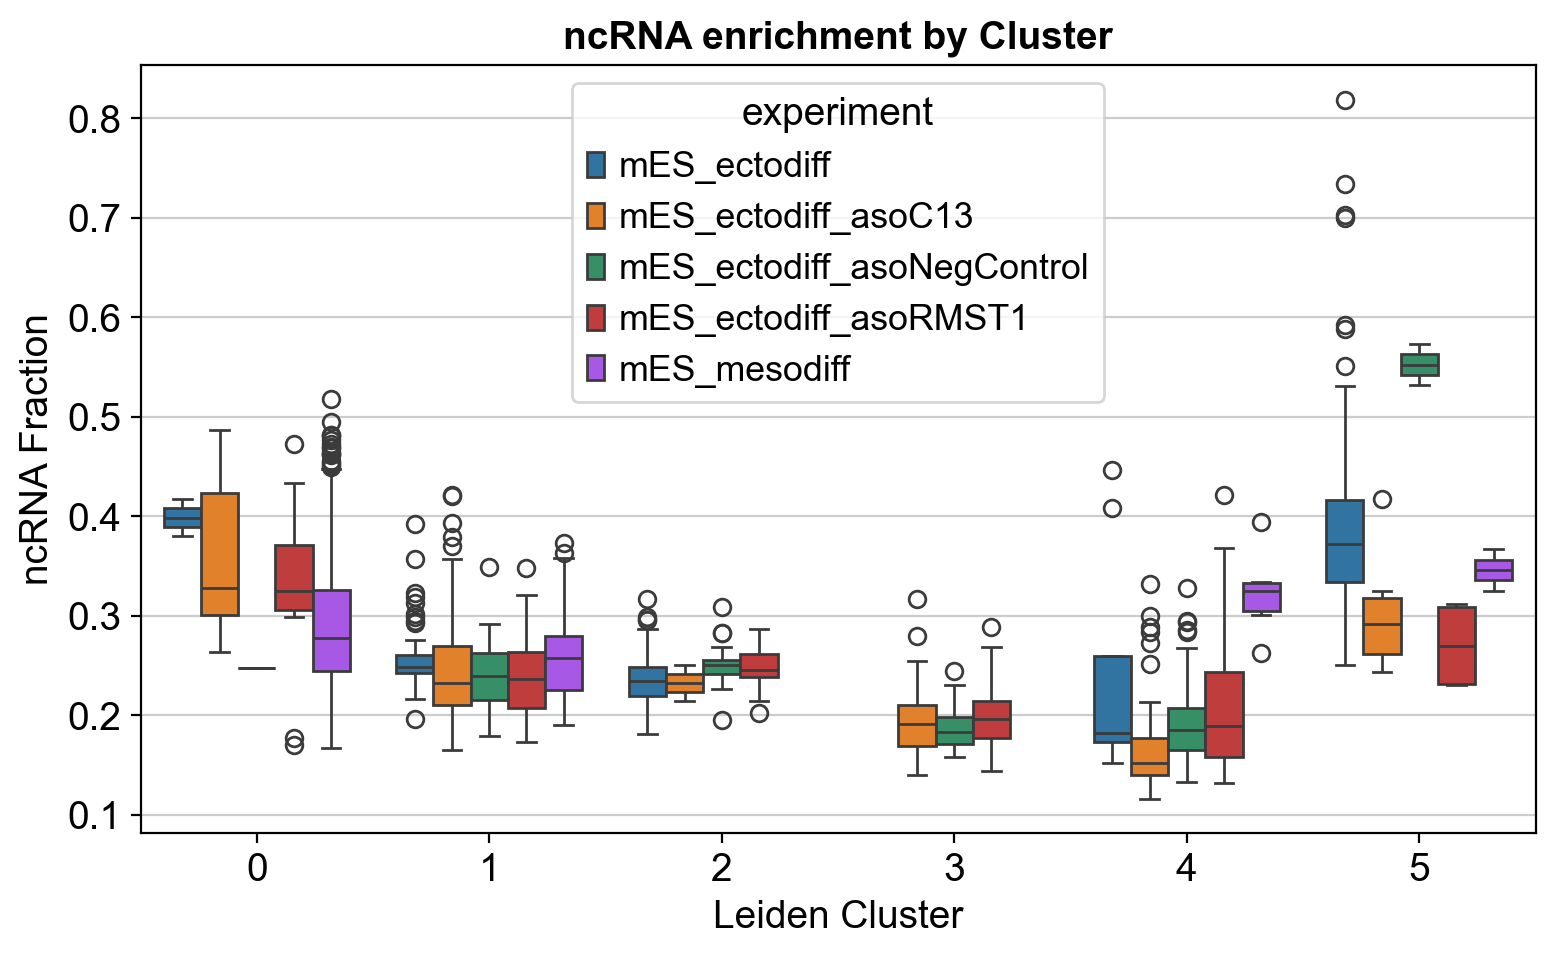

In [12]:
# Non-coding fraction
is_protein = adata_lncRNA.raw.var['is_protein_coding'].fillna(False)
non_coding_mask = (~is_protein)

print(f"Total genes in raw data: {adata_lncRNA.raw.n_vars}")
print(f"Protein coding genes: {is_protein.sum()}")
print(f"ALL Non-coding genes (small, lnc, ...): {non_coding_mask.sum()}")

# Extract counts directly from the RAW matrix
if issparse(adata_lncRNA.raw.X):
    nc_counts = np.array(adata_lncRNA.raw[:, non_coding_mask].X.sum(axis=1)).flatten()
    # Total biological counts
    tot_biological_counts = np.array(adata_lncRNA.raw.X.sum(axis=1)).flatten()
else:
    nc_counts = adata_lncRNA.raw[:, non_coding_mask].X.sum(axis=1)
    tot_biological_counts = adata_lncRNA.raw.X.sum(axis=1)

# Safety
tot_biological_counts[tot_biological_counts == 0] = 1 

# The metric: ncRNA fraction
adata_lncRNA.obs['total_non_coding_fraction'] = nc_counts / tot_biological_counts

# PLOT: Global Distribution by Experiment (Kernel Density)
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=adata_lncRNA.obs, 
    x='total_non_coding_fraction', 
    hue='experiment', 
    common_norm=False, 
    fill=True, 
    alpha=0.2,
    linewidth=2
)
plt.title("ncRNA Fraction Distribution", fontweight='bold')
plt.xlabel("ncRNA Fraction")
plt.ylabel("Density")
# Move legend outside
plt.legend(title='Experiment', labels=adata_lncRNA.obs['experiment'].unique(), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# PLOT: Check the specific Leiden Clusters
sc.tl.pca(adata_lncRNA, svd_solver='arpack')
sc.pp.neighbors(adata_lncRNA, n_neighbors=30, n_pcs=19)

sc.tl.leiden(adata_lncRNA, resolution=0.4, random_state=12)
sc.tl.dendrogram(adata_lncRNA, groupby='leiden')

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=adata_lncRNA.obs,
    x='leiden', 
    y='total_non_coding_fraction',
    hue='experiment'
)
plt.title("ncRNA enrichment by Cluster", fontweight='bold')
plt.xlabel("Leiden Cluster")
plt.ylabel("ncRNA Fraction")
plt.tight_layout()
plt.show()

Let's check the distribution of biotypes for each protocol:

Found 61 unique biotypes in the dataset.


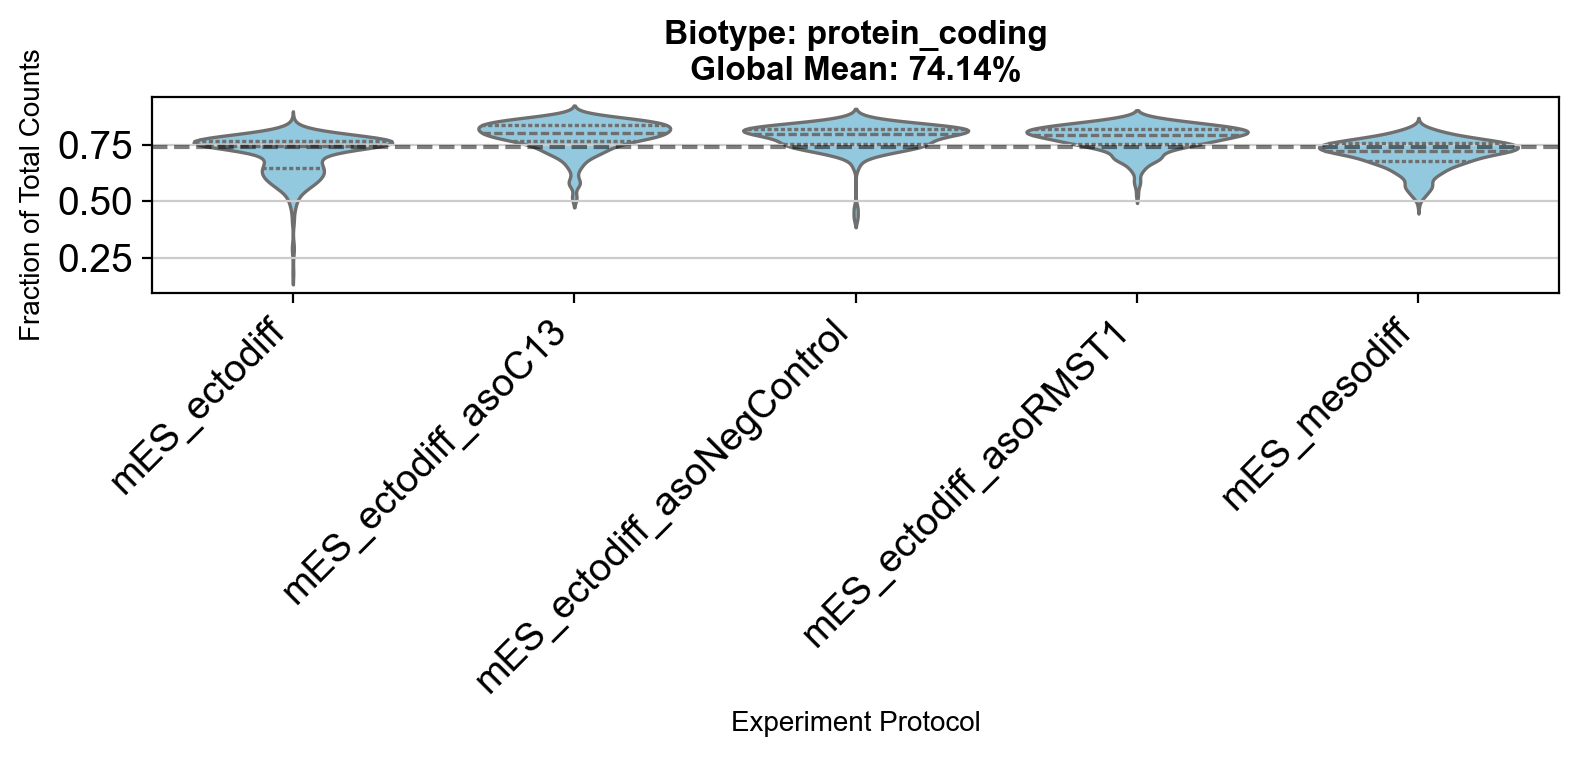

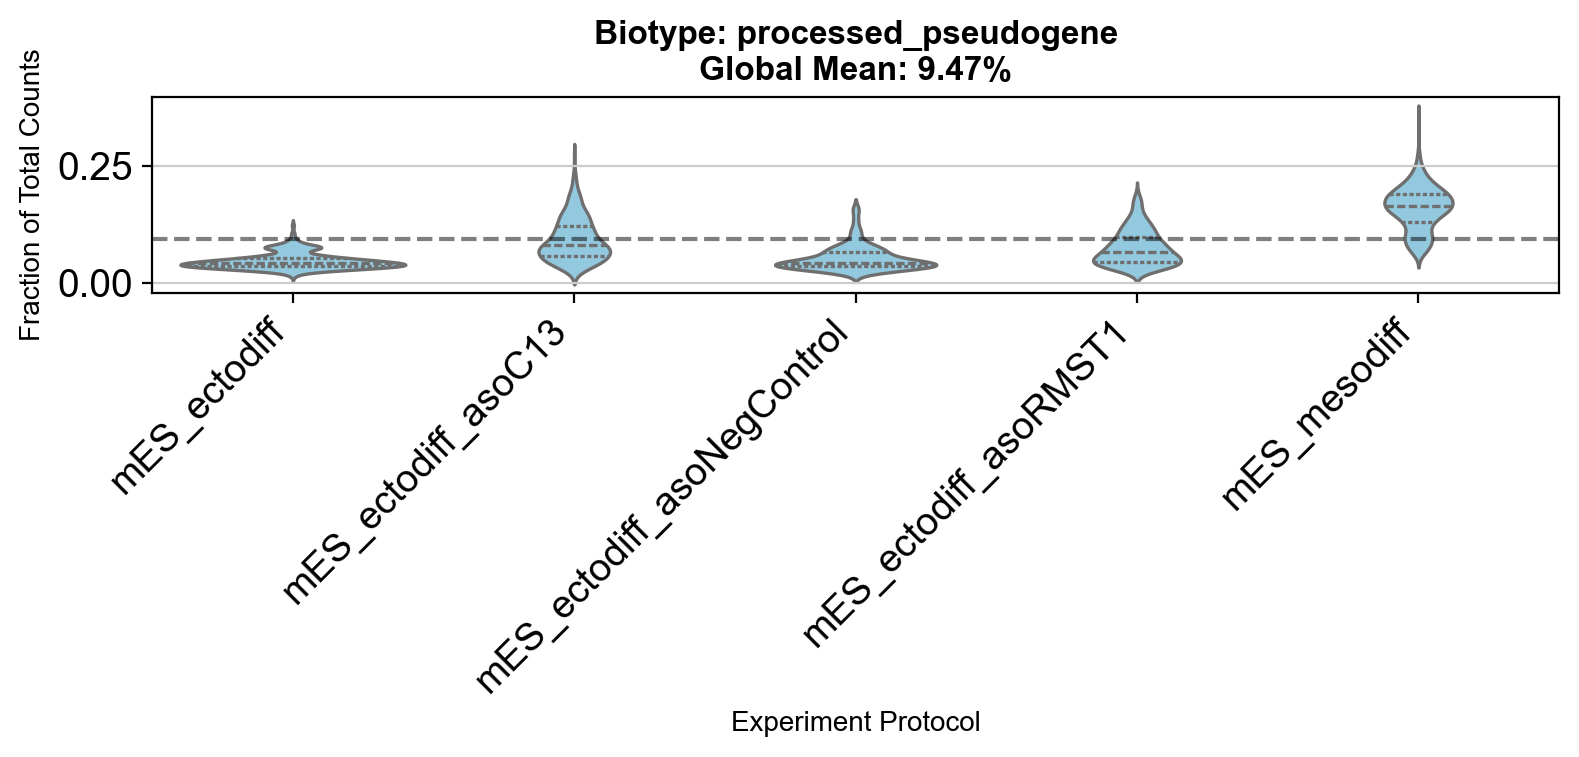

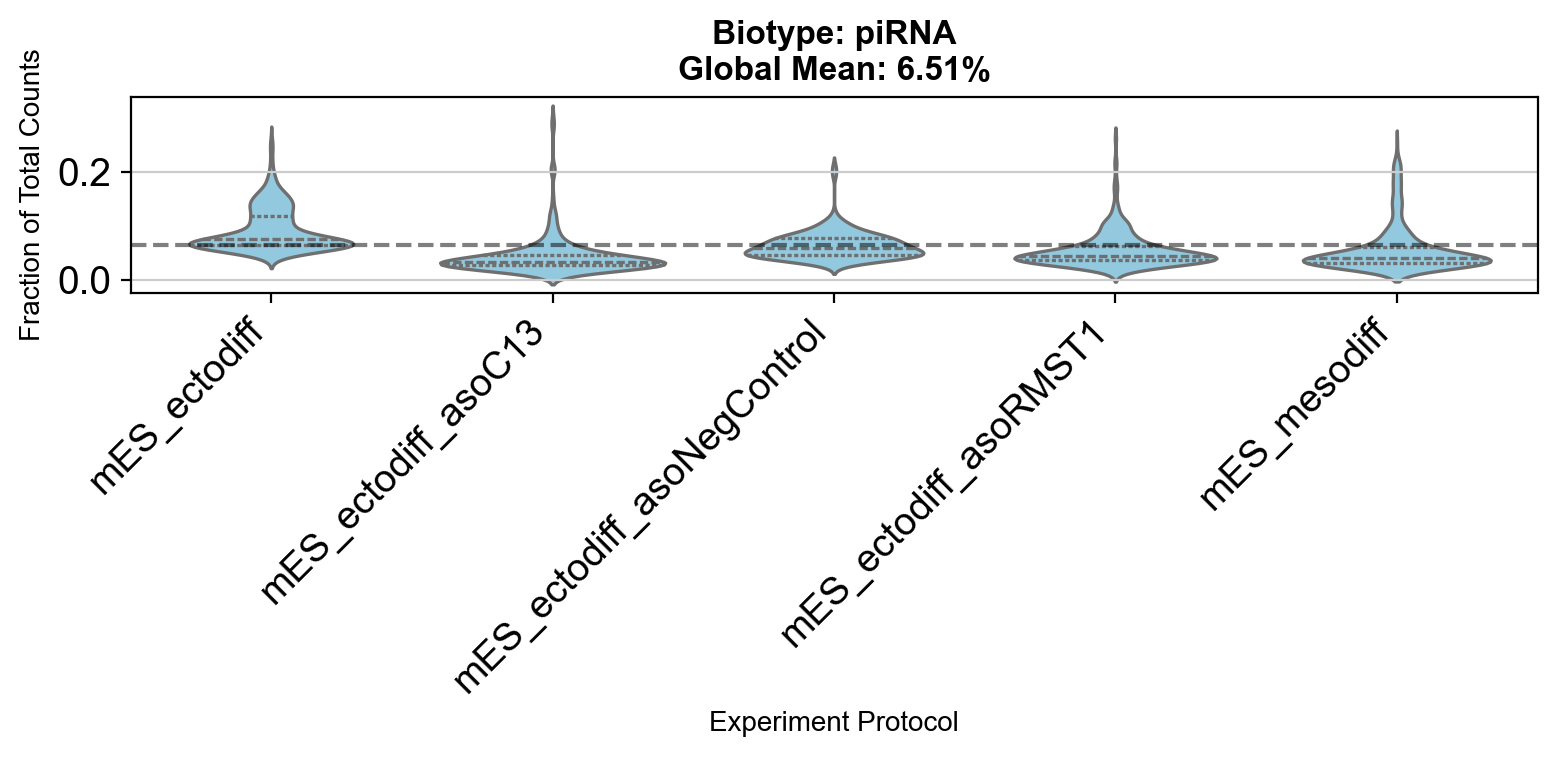

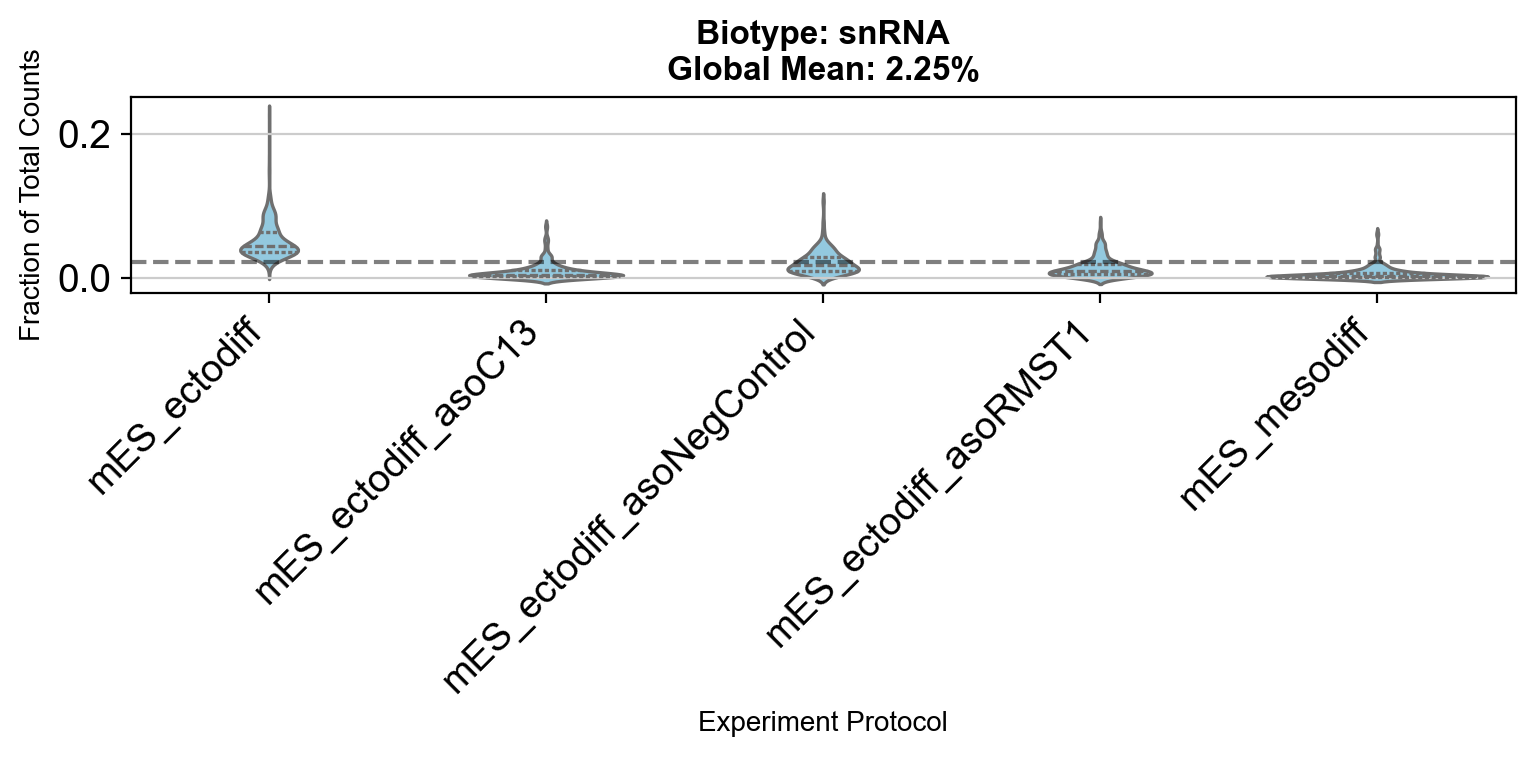

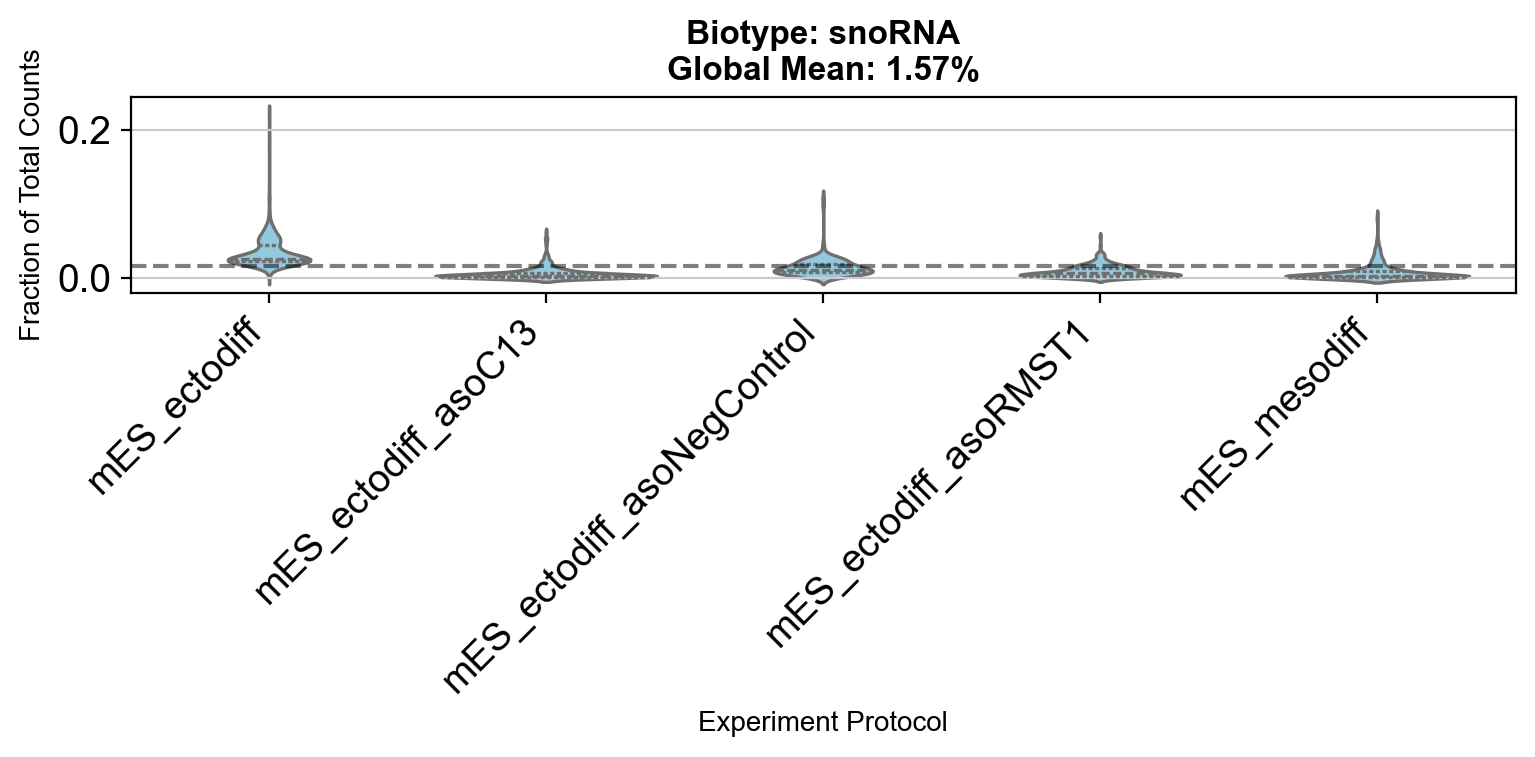

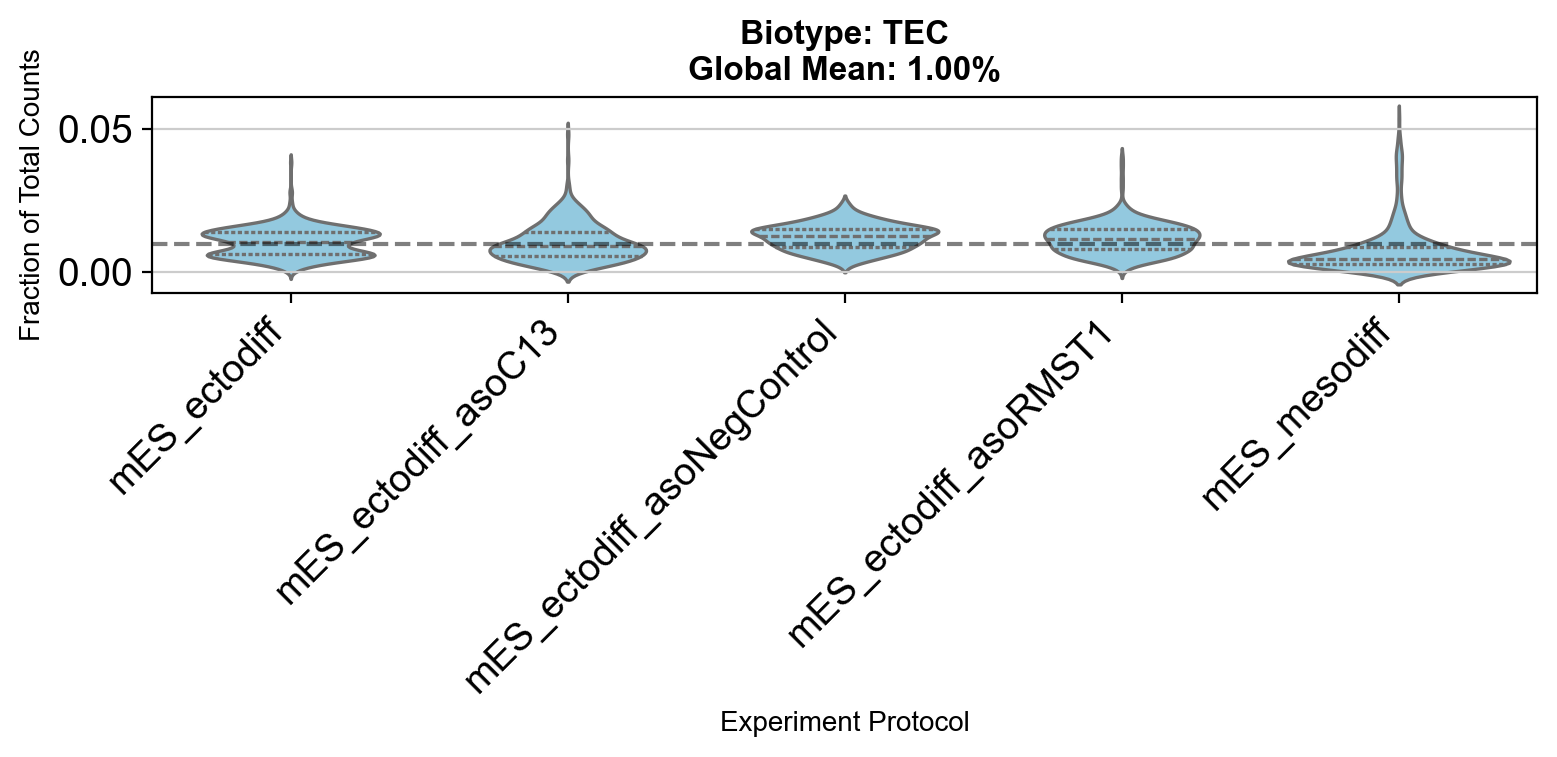

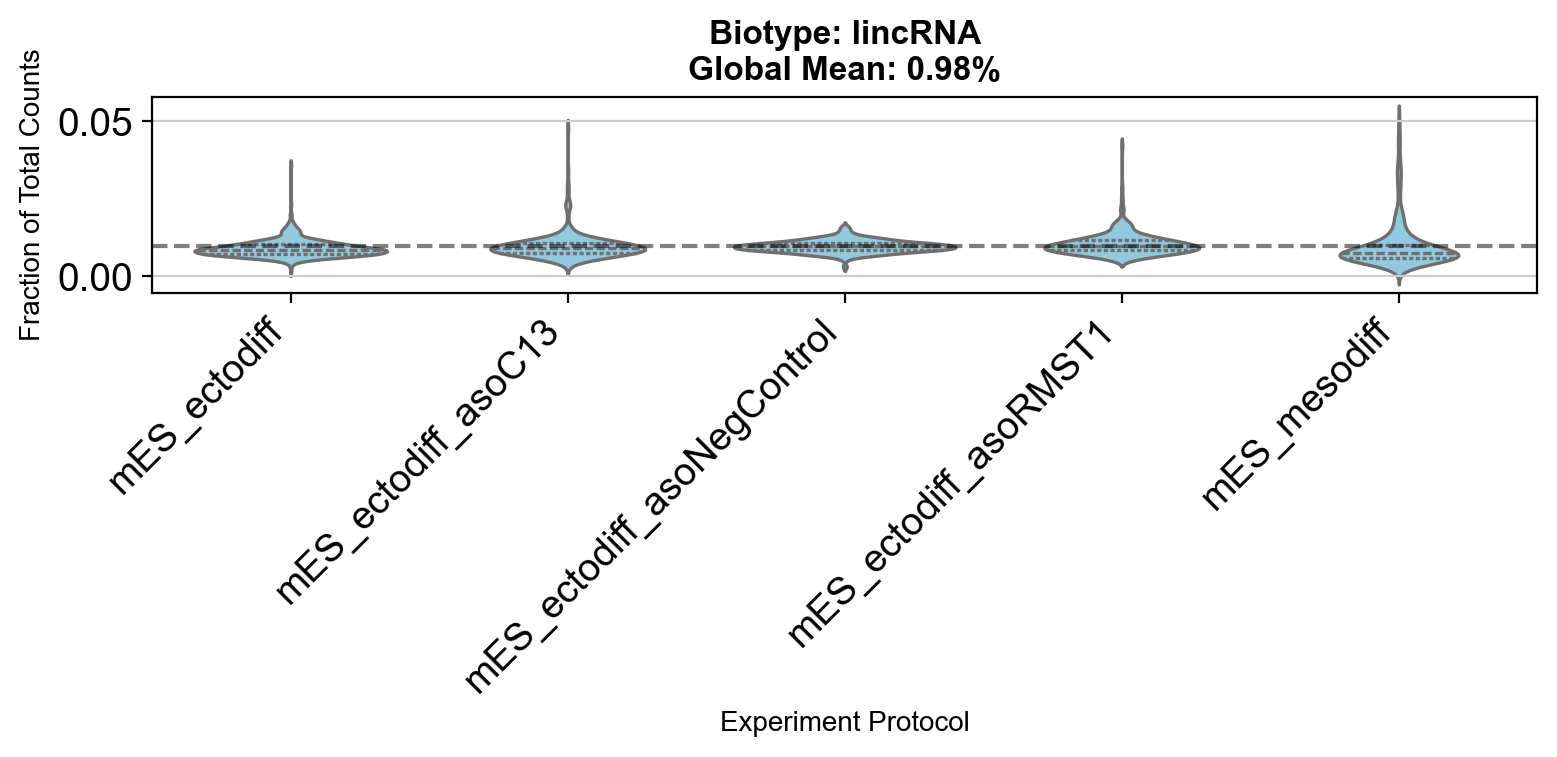

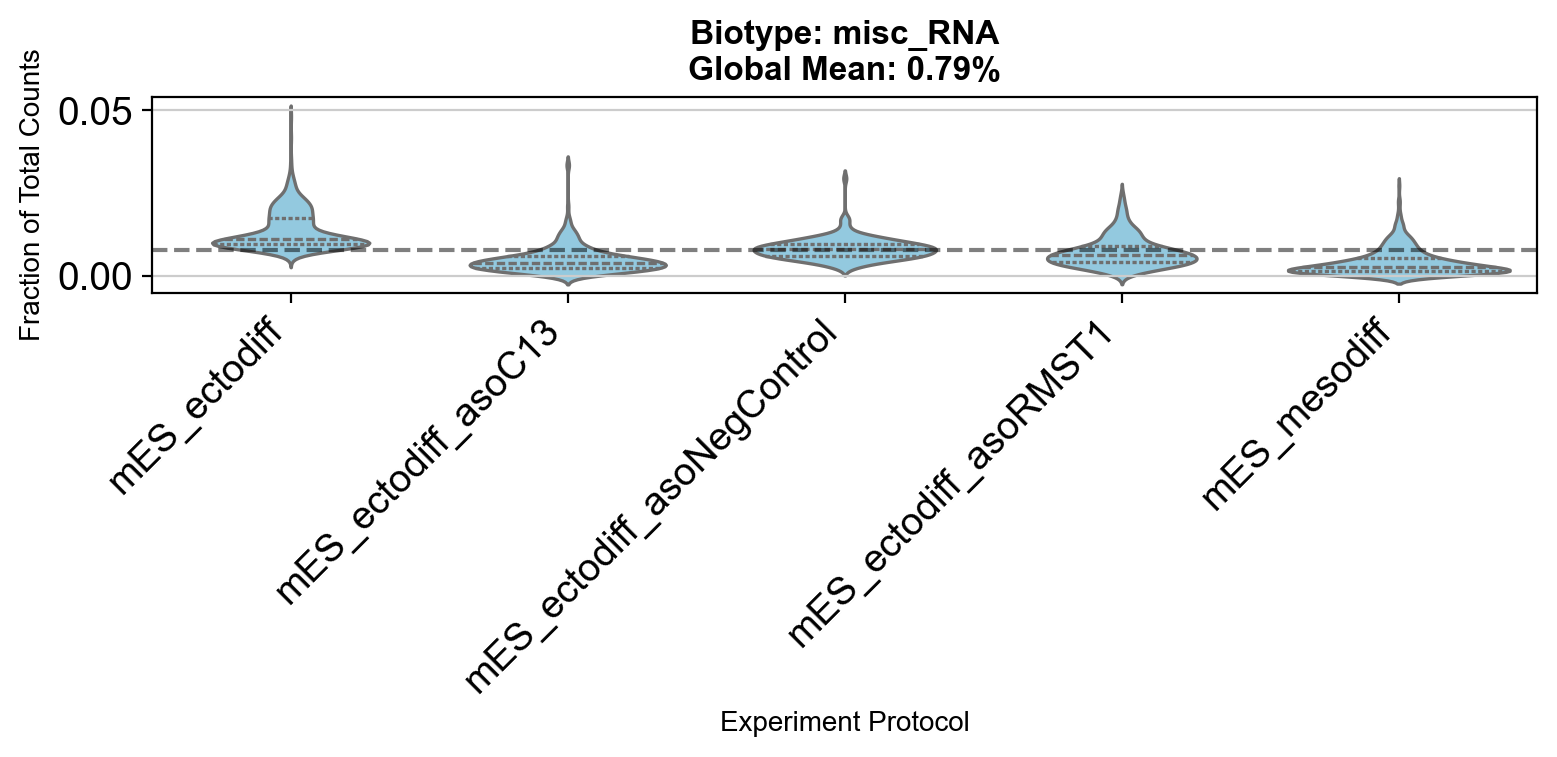

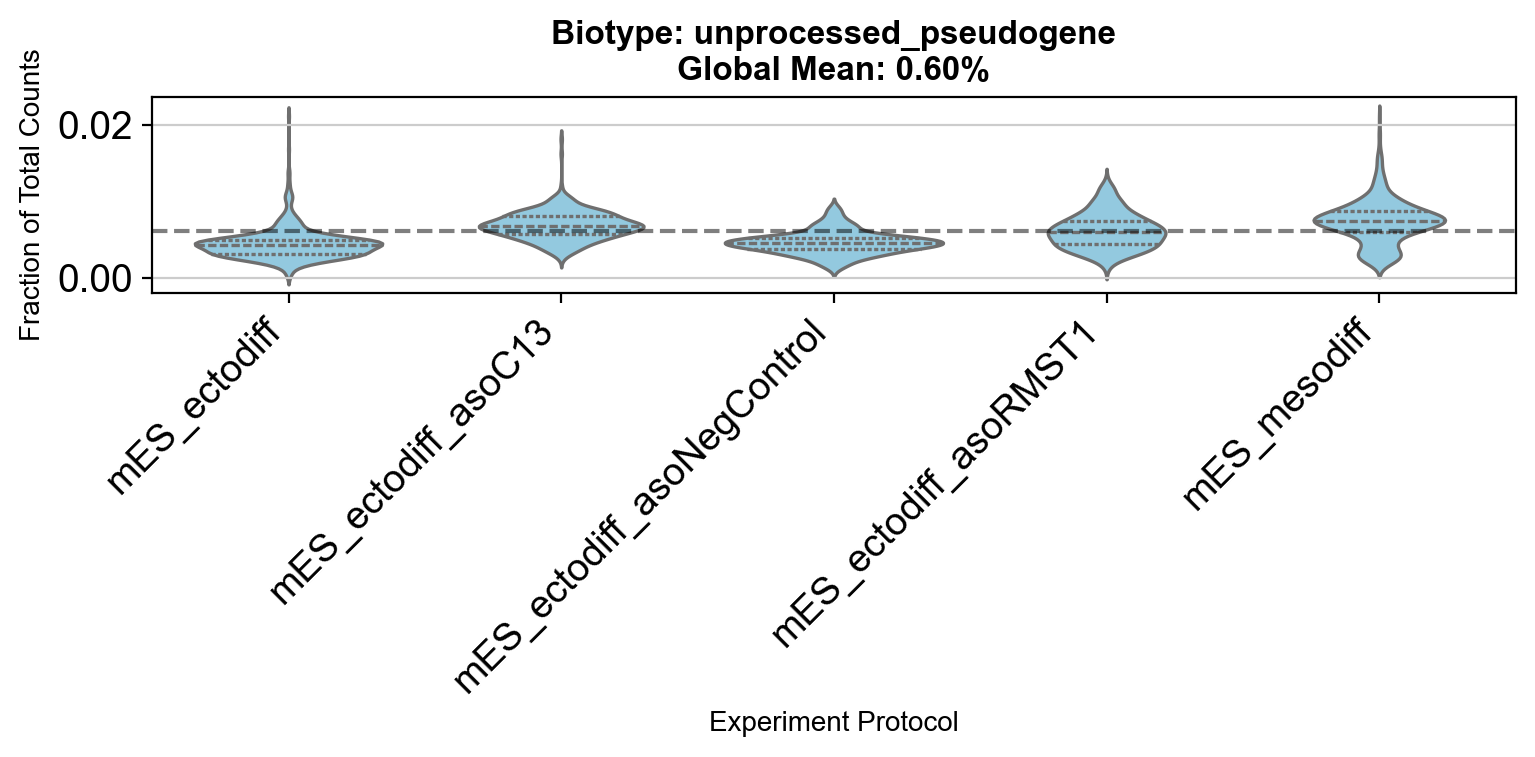

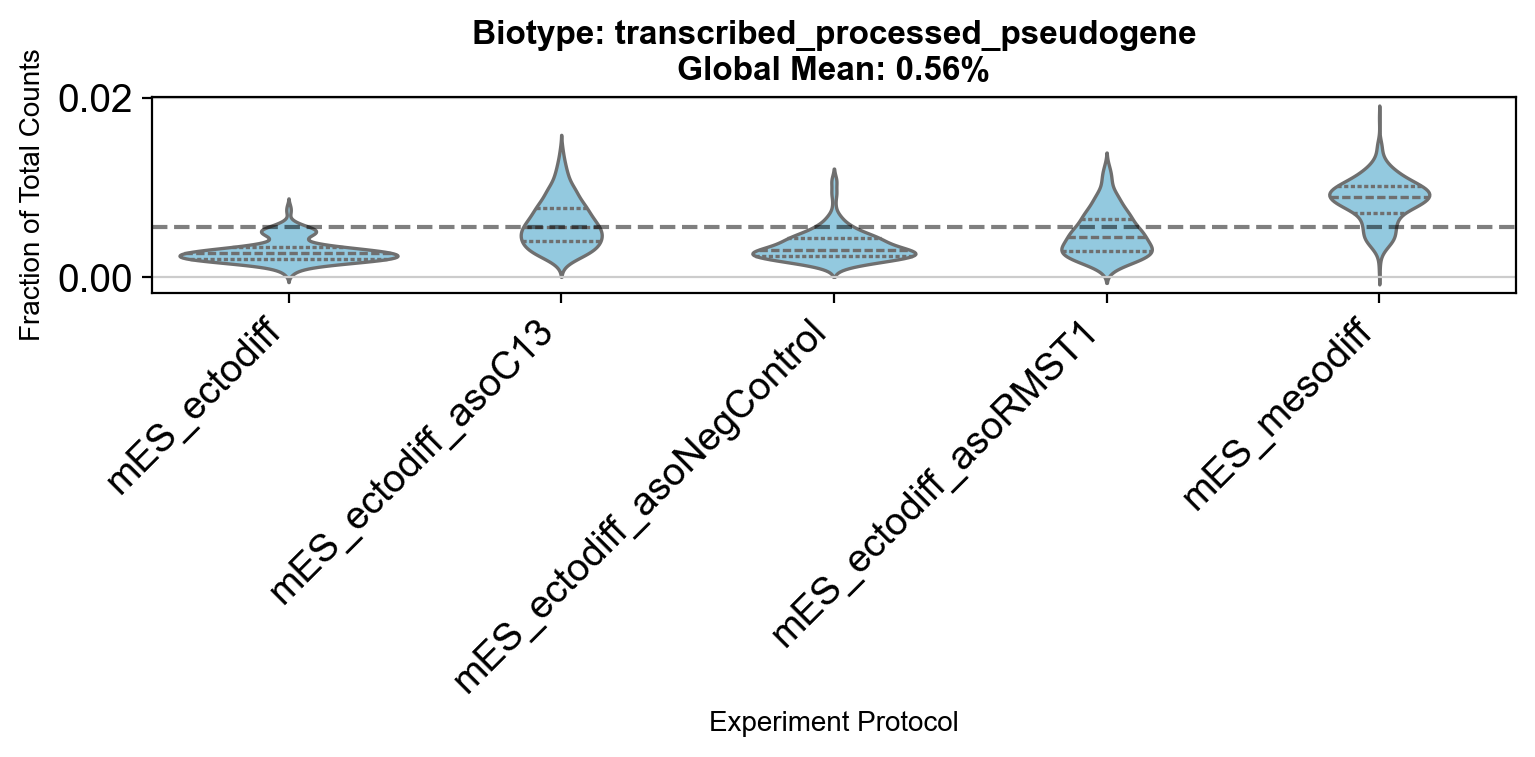

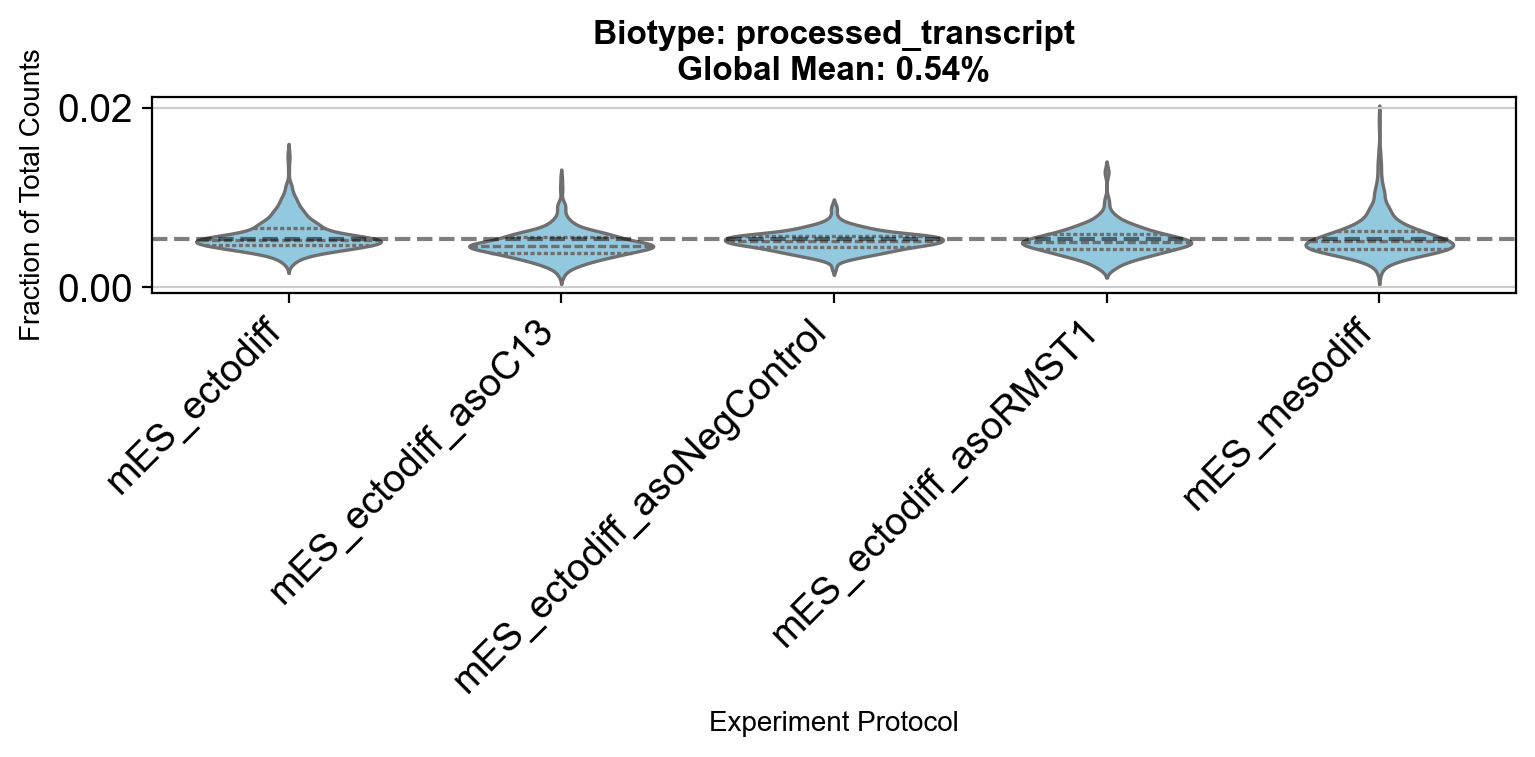

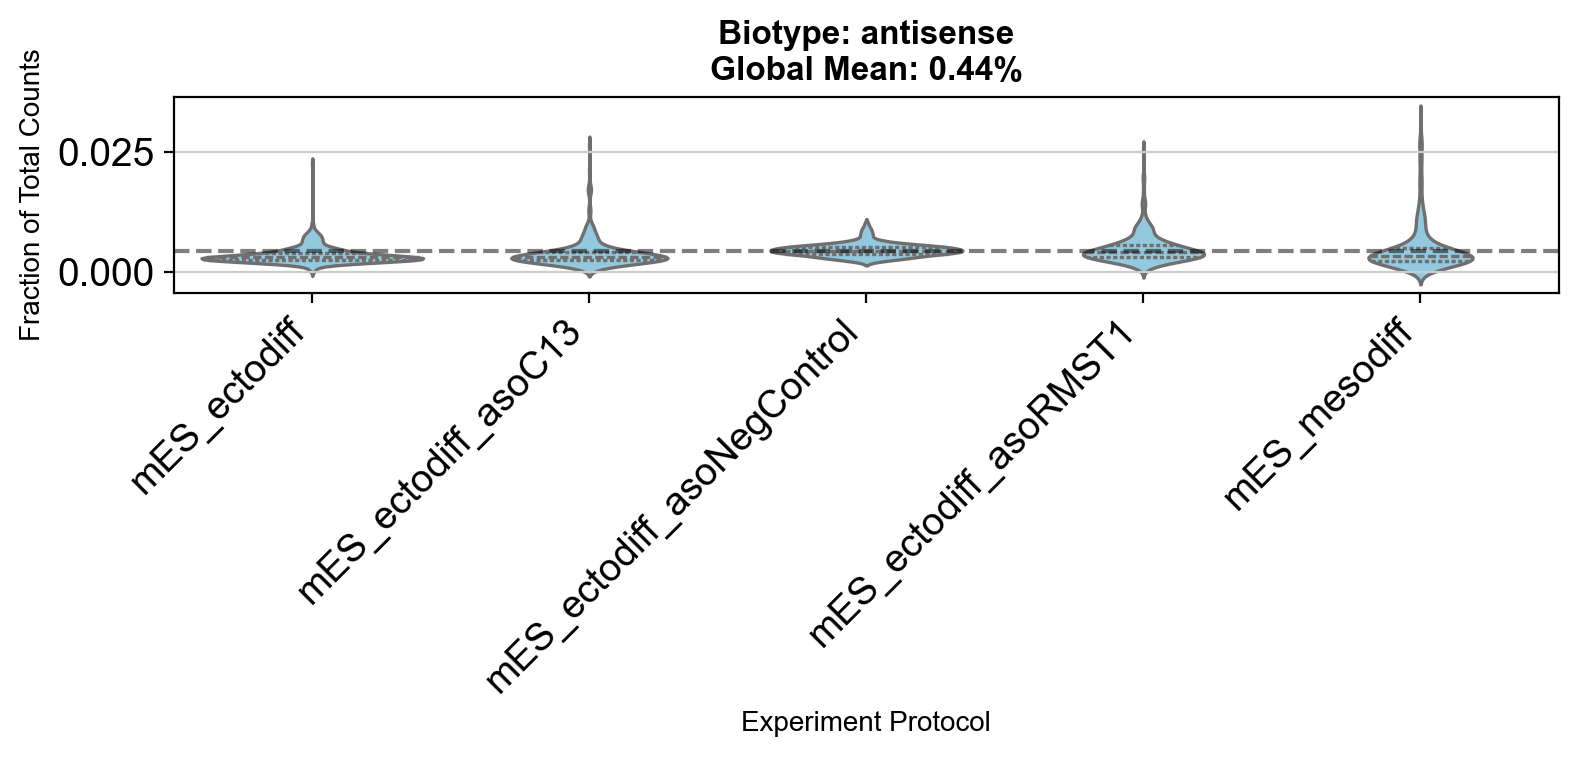

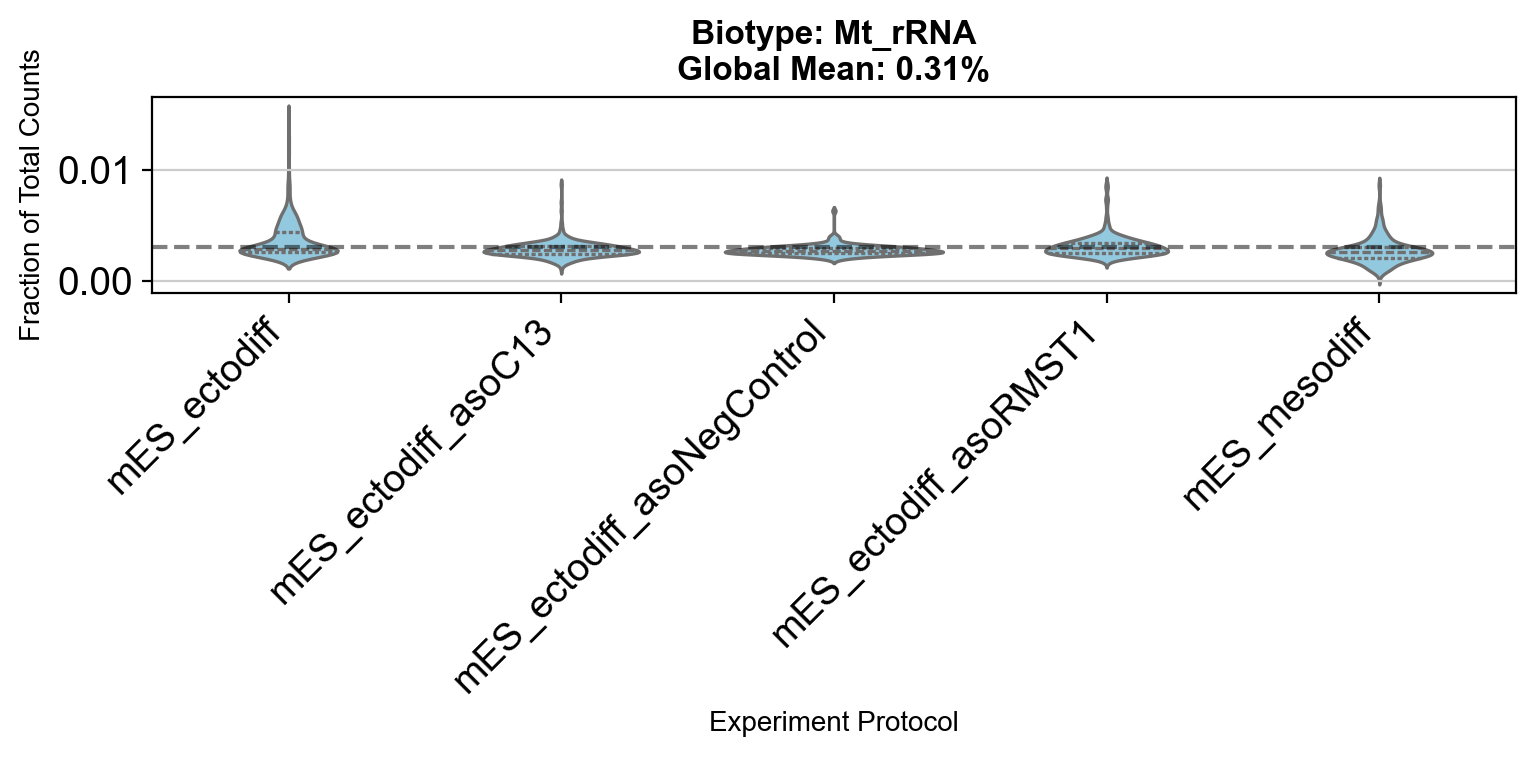

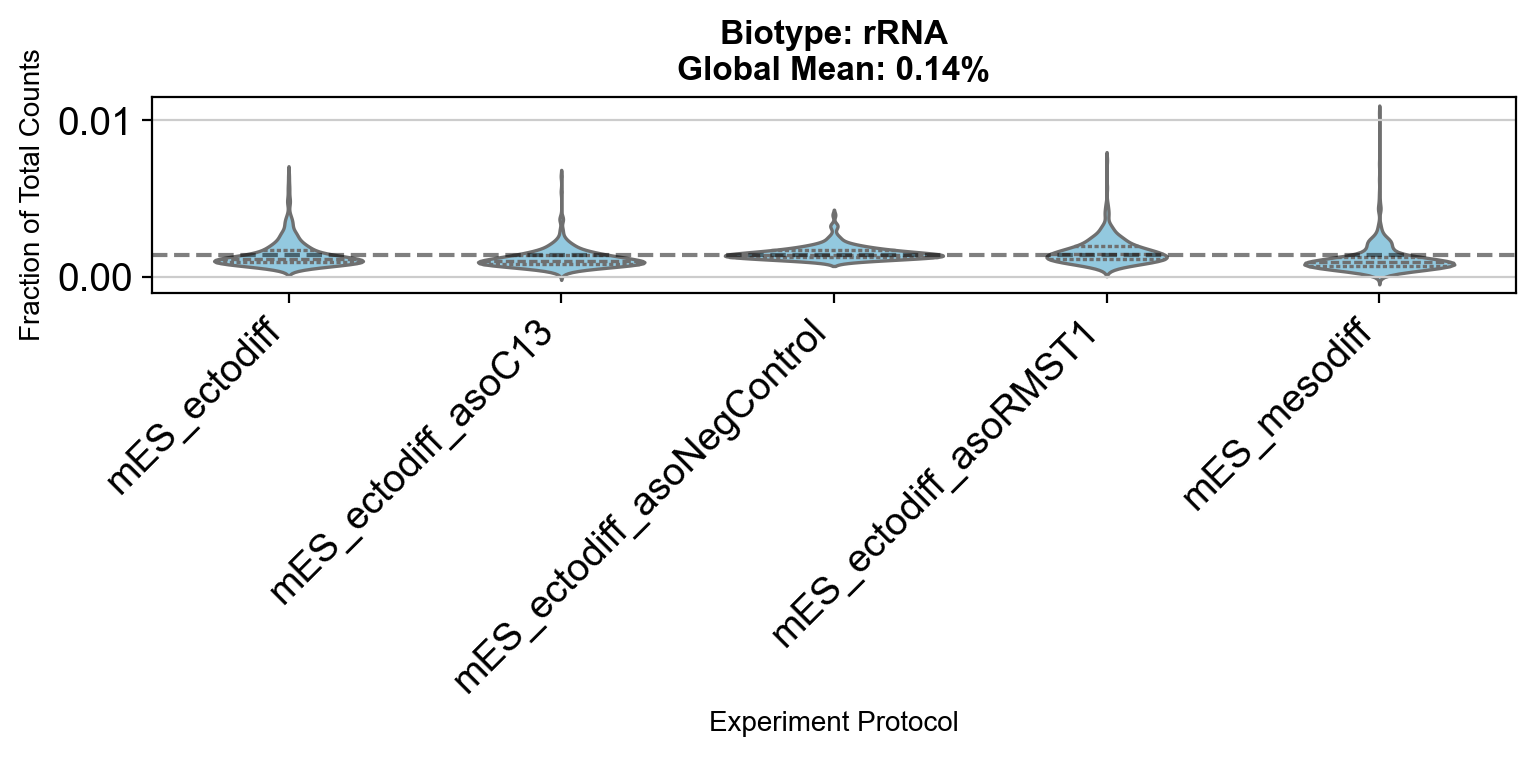

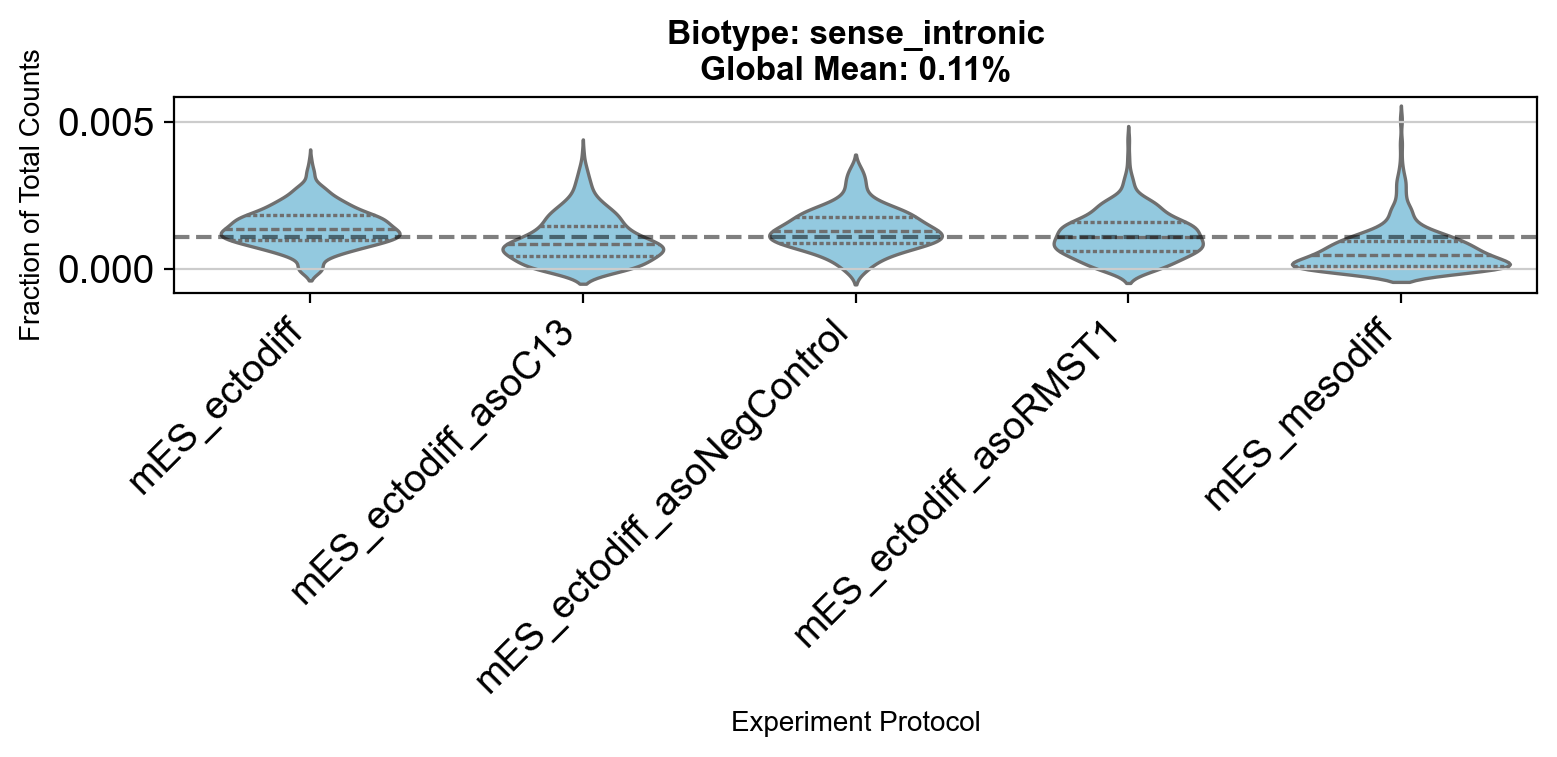

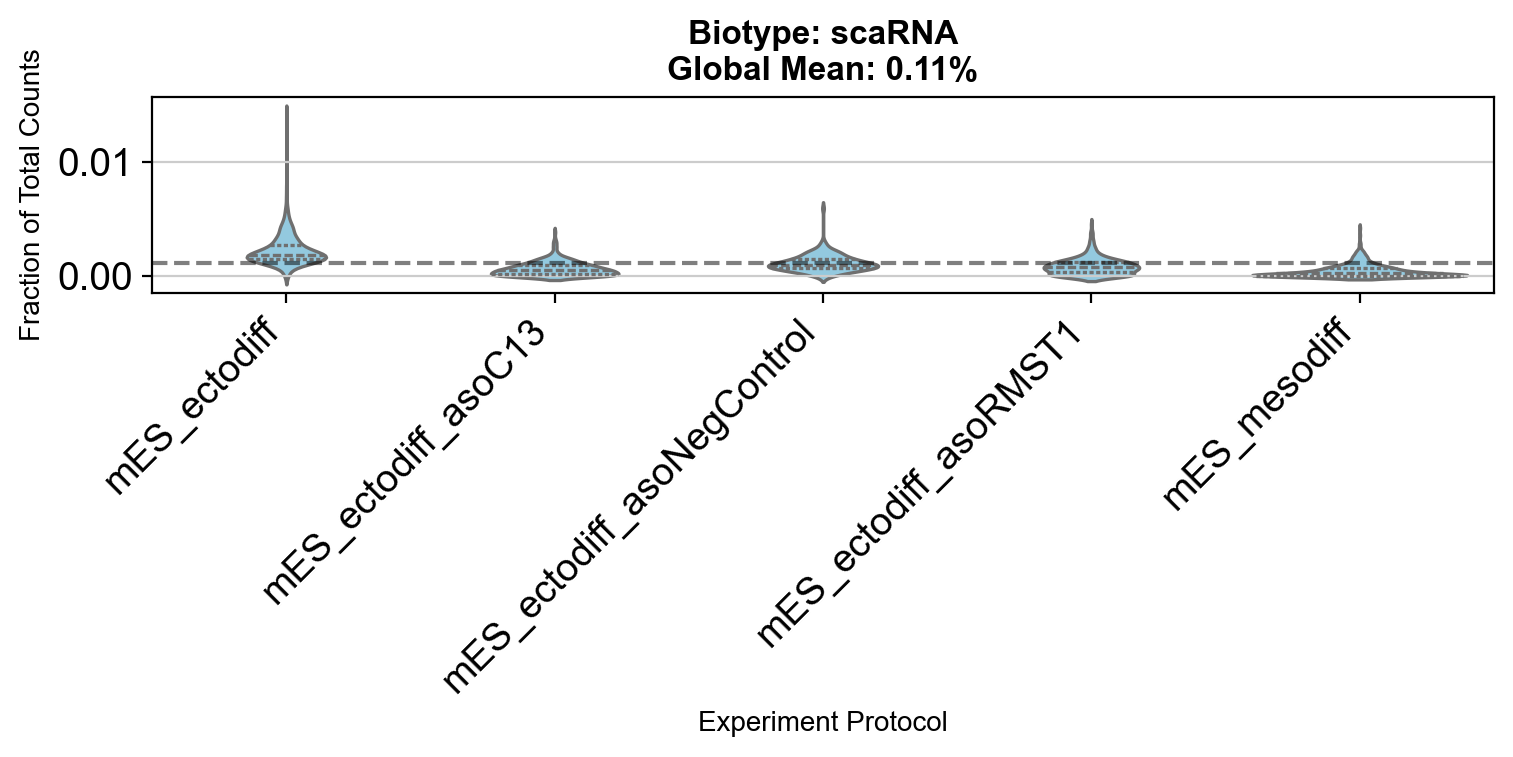

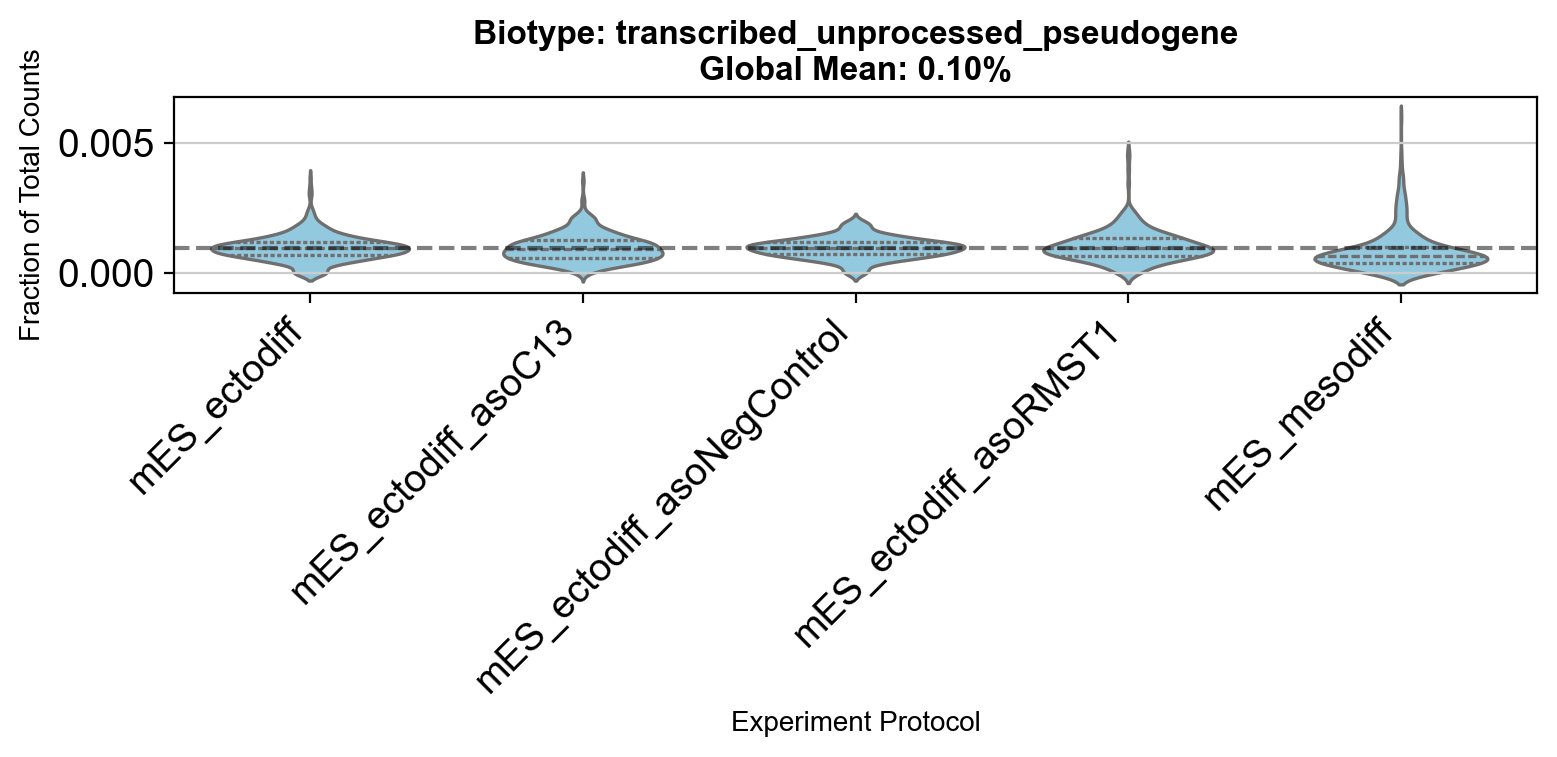

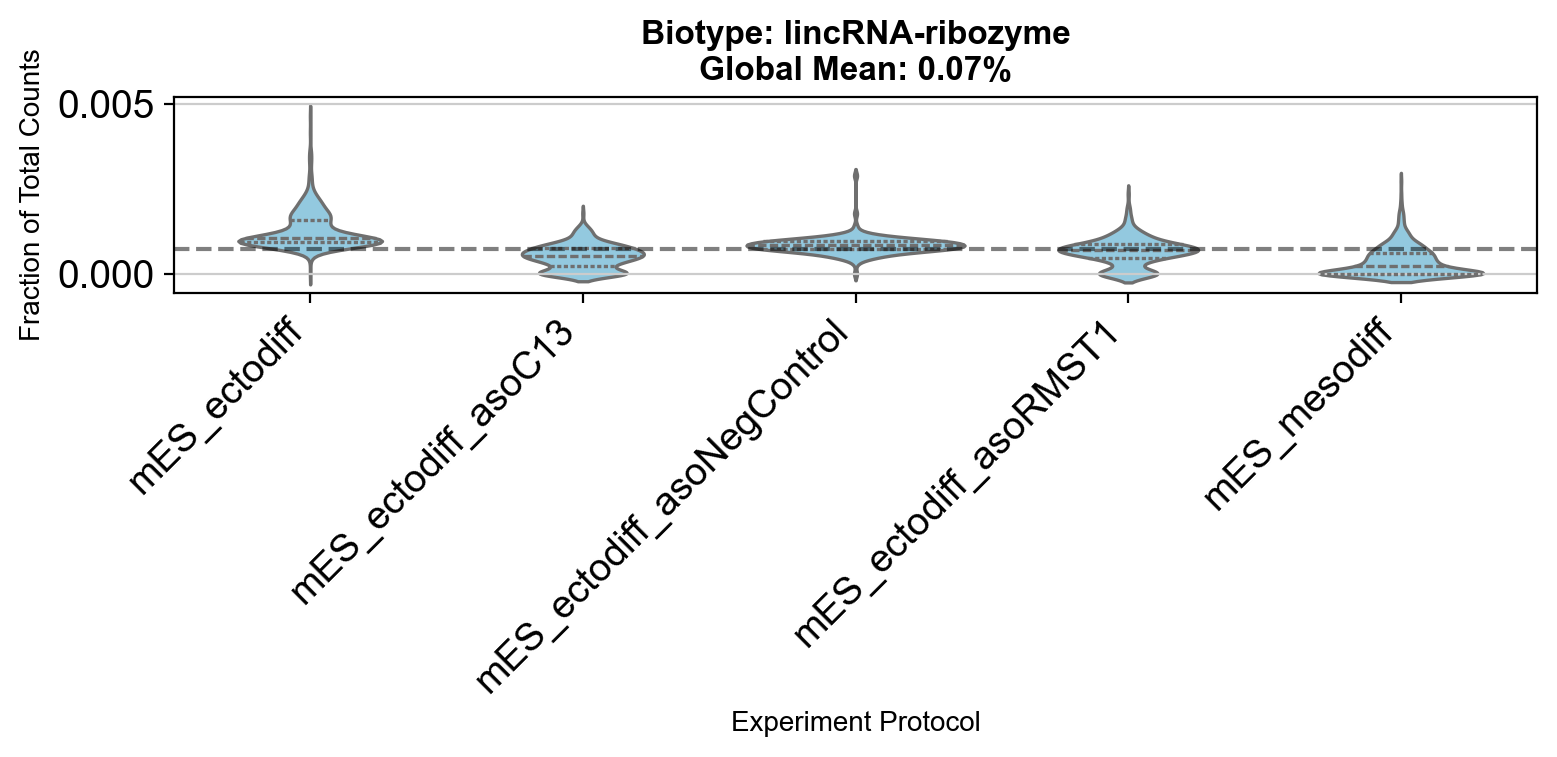

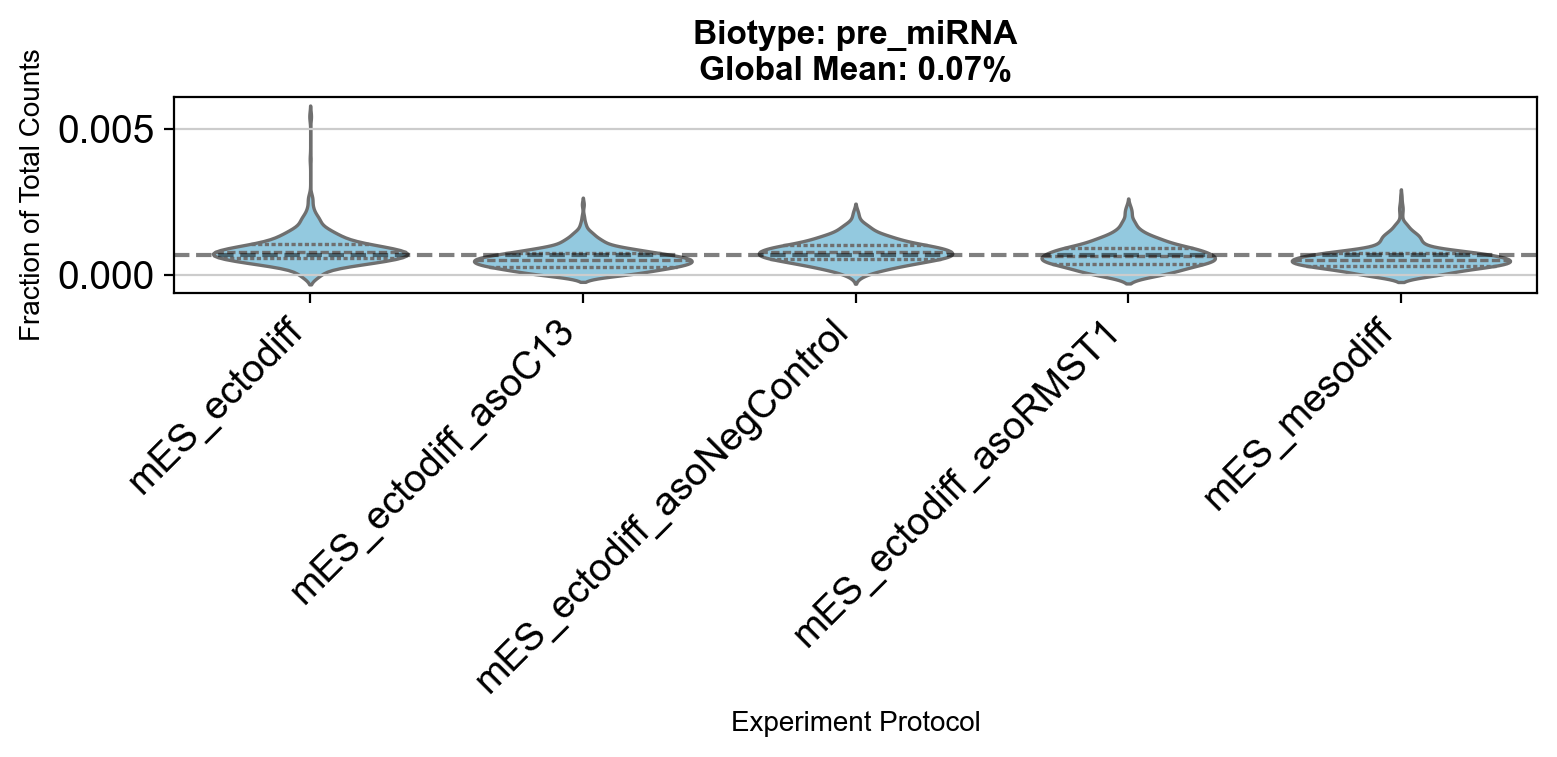

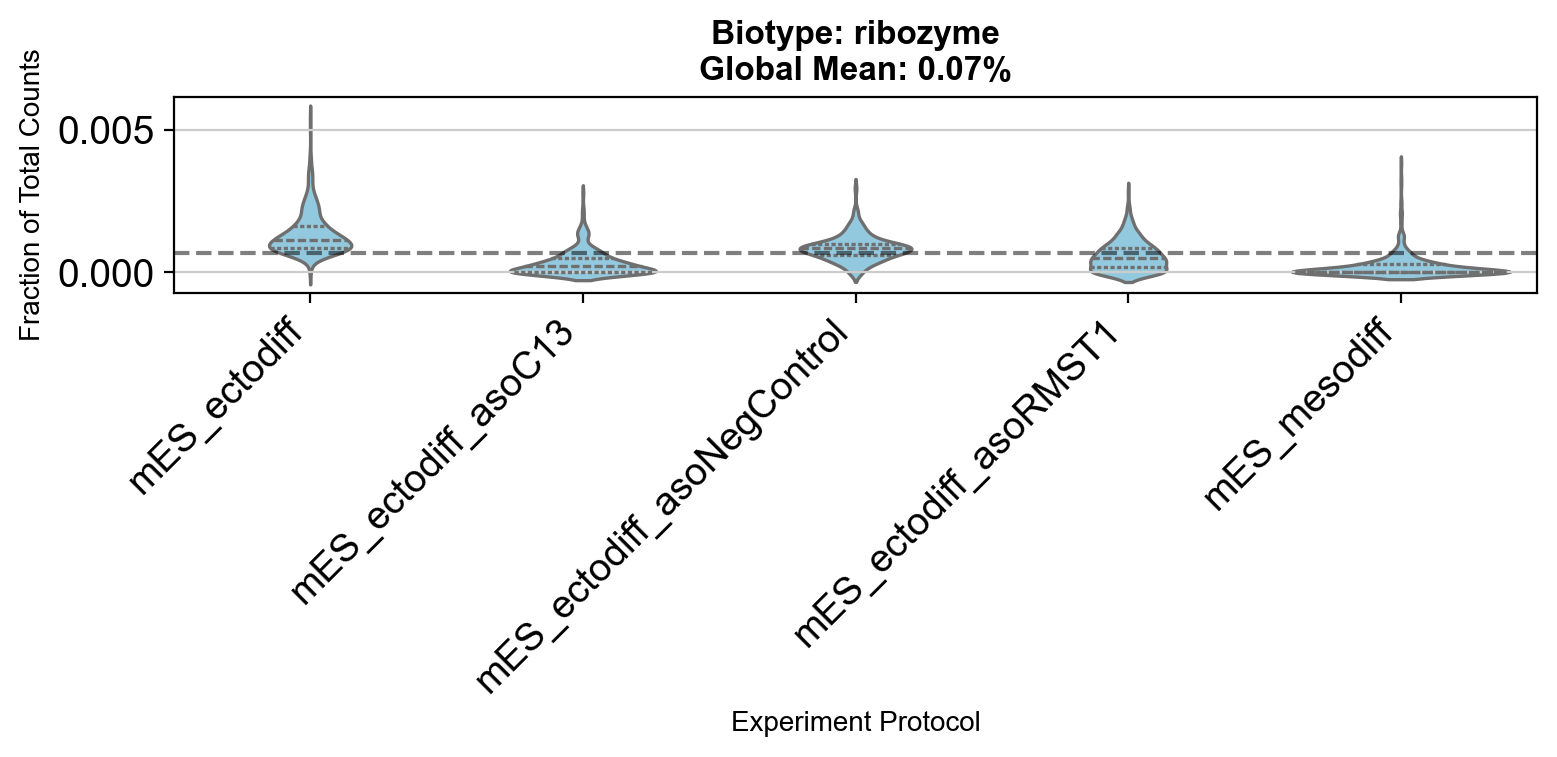

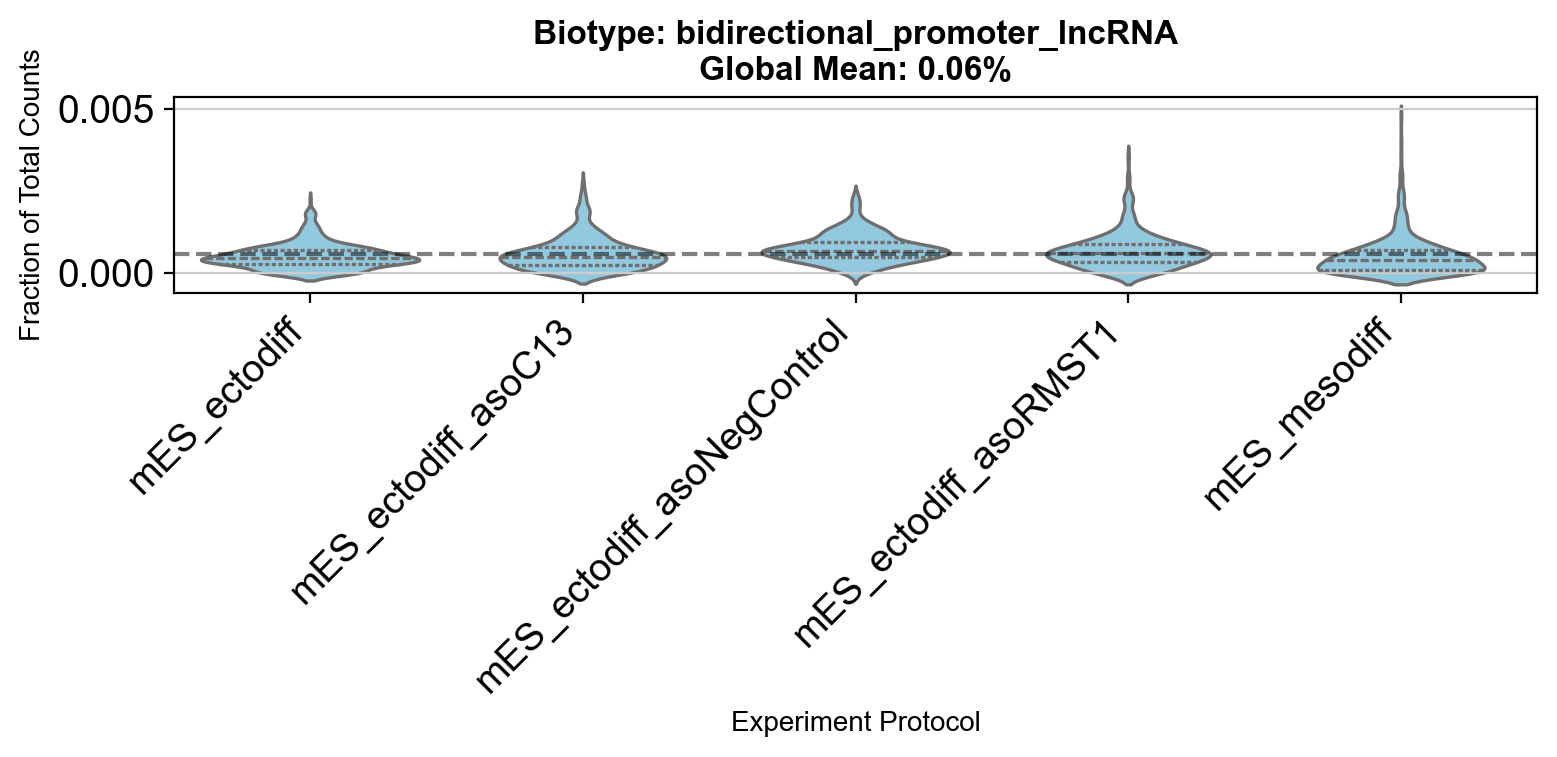

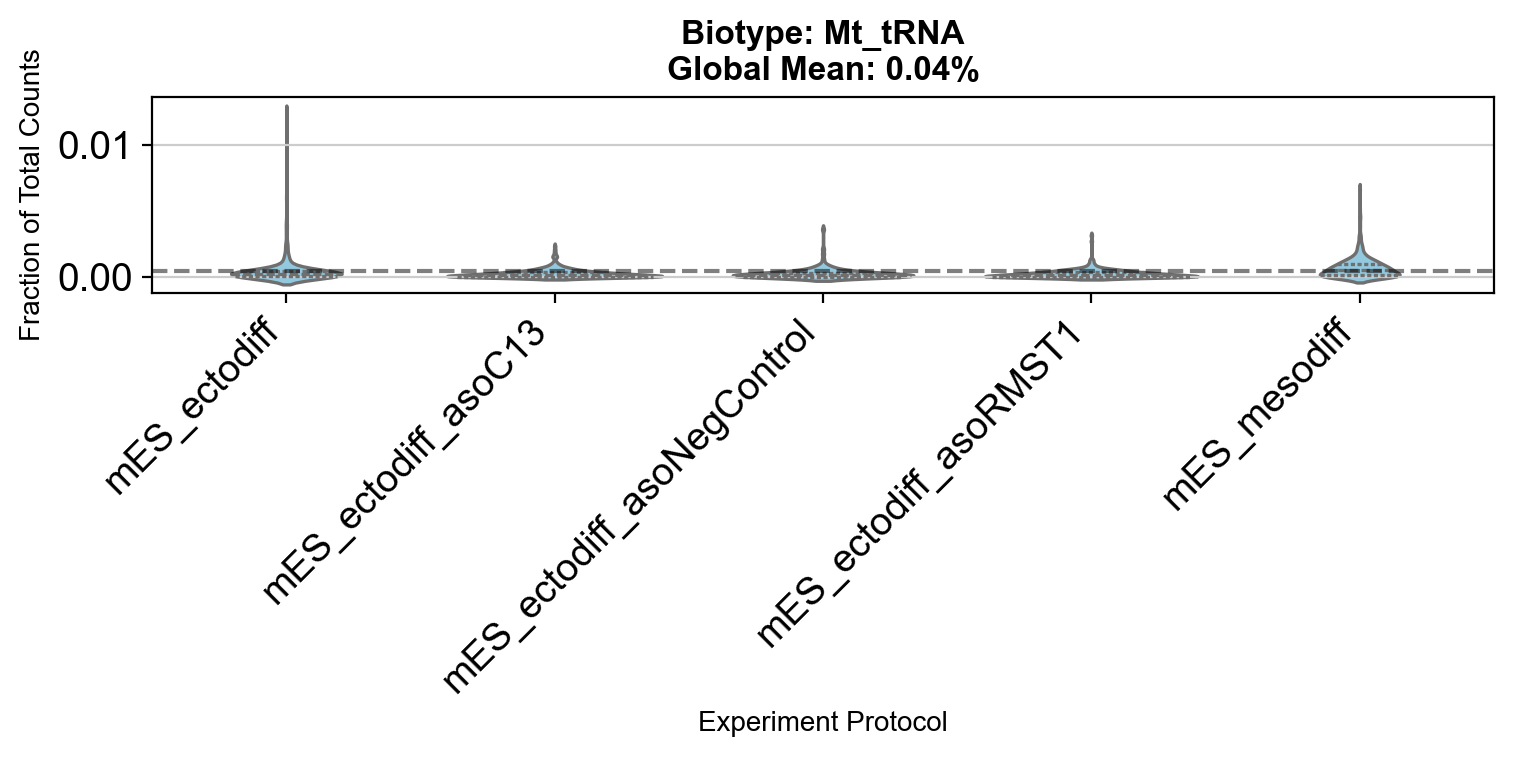

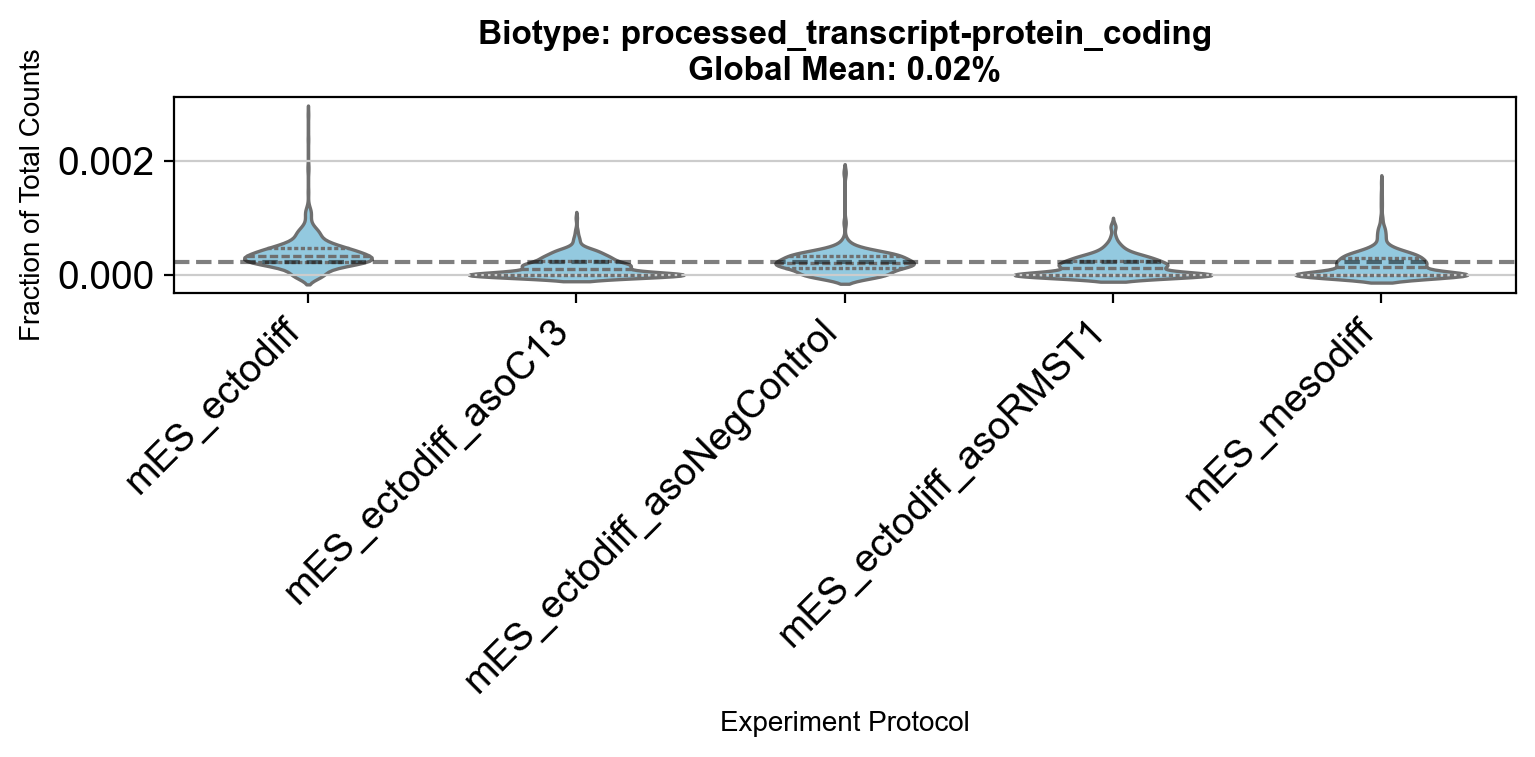

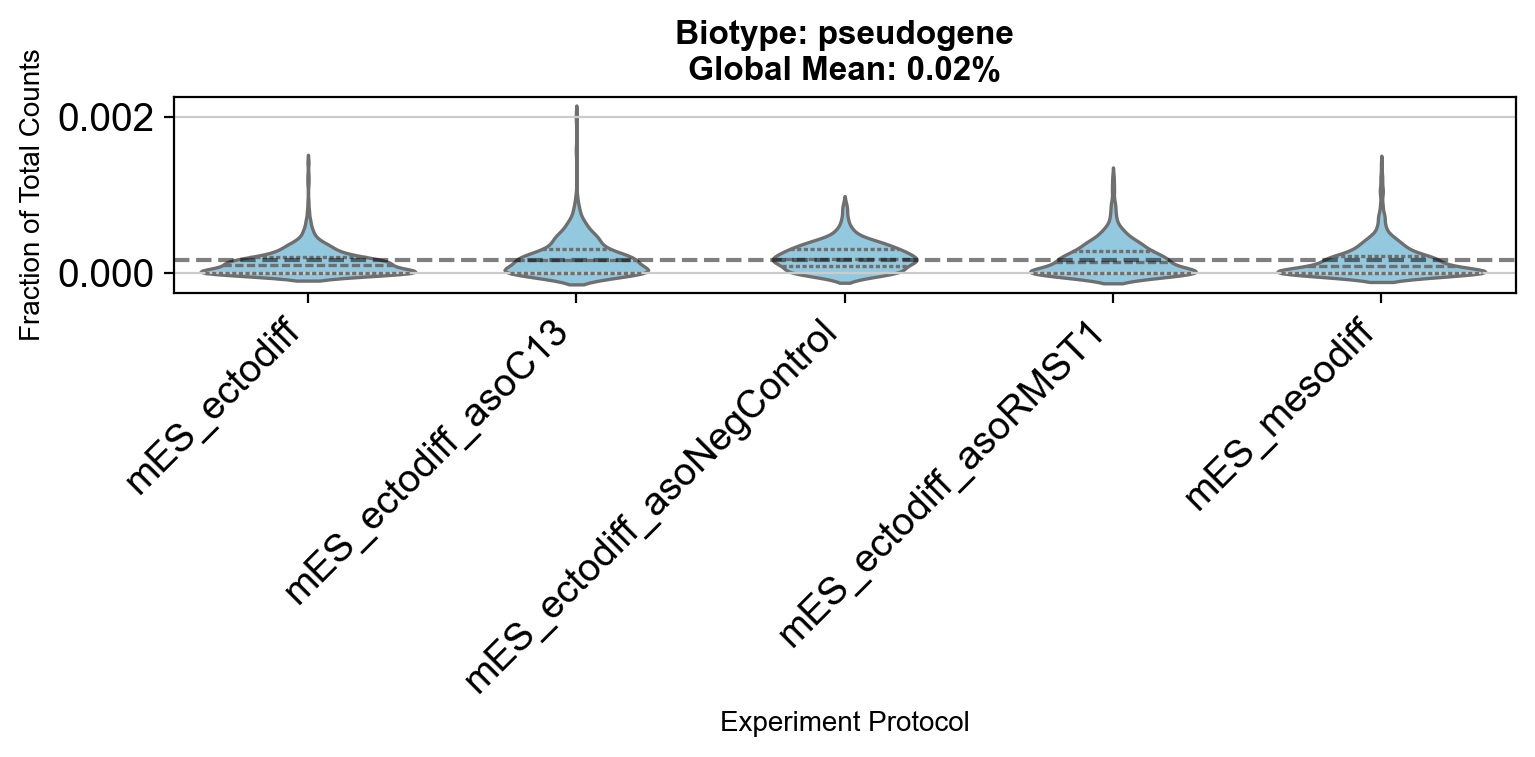

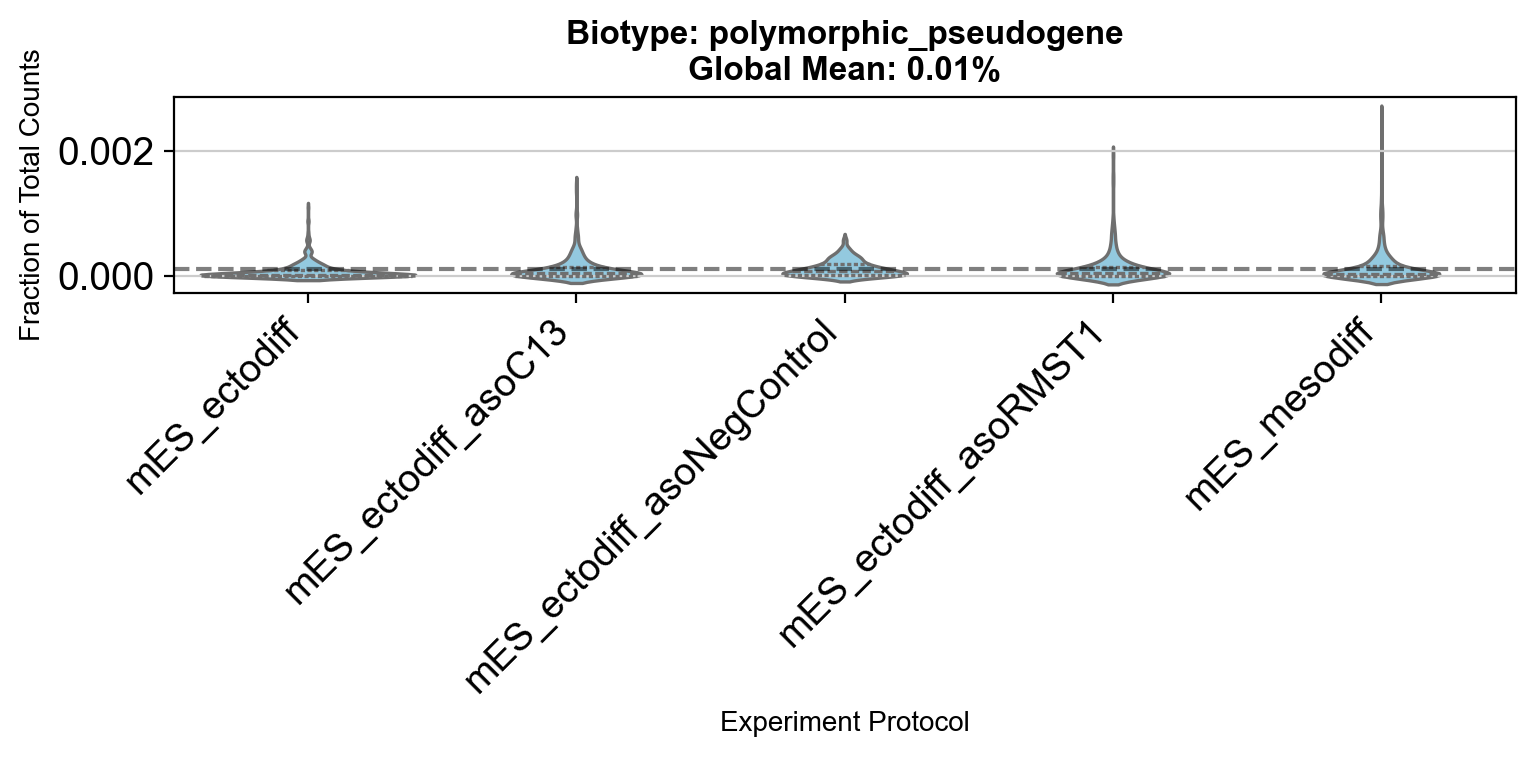

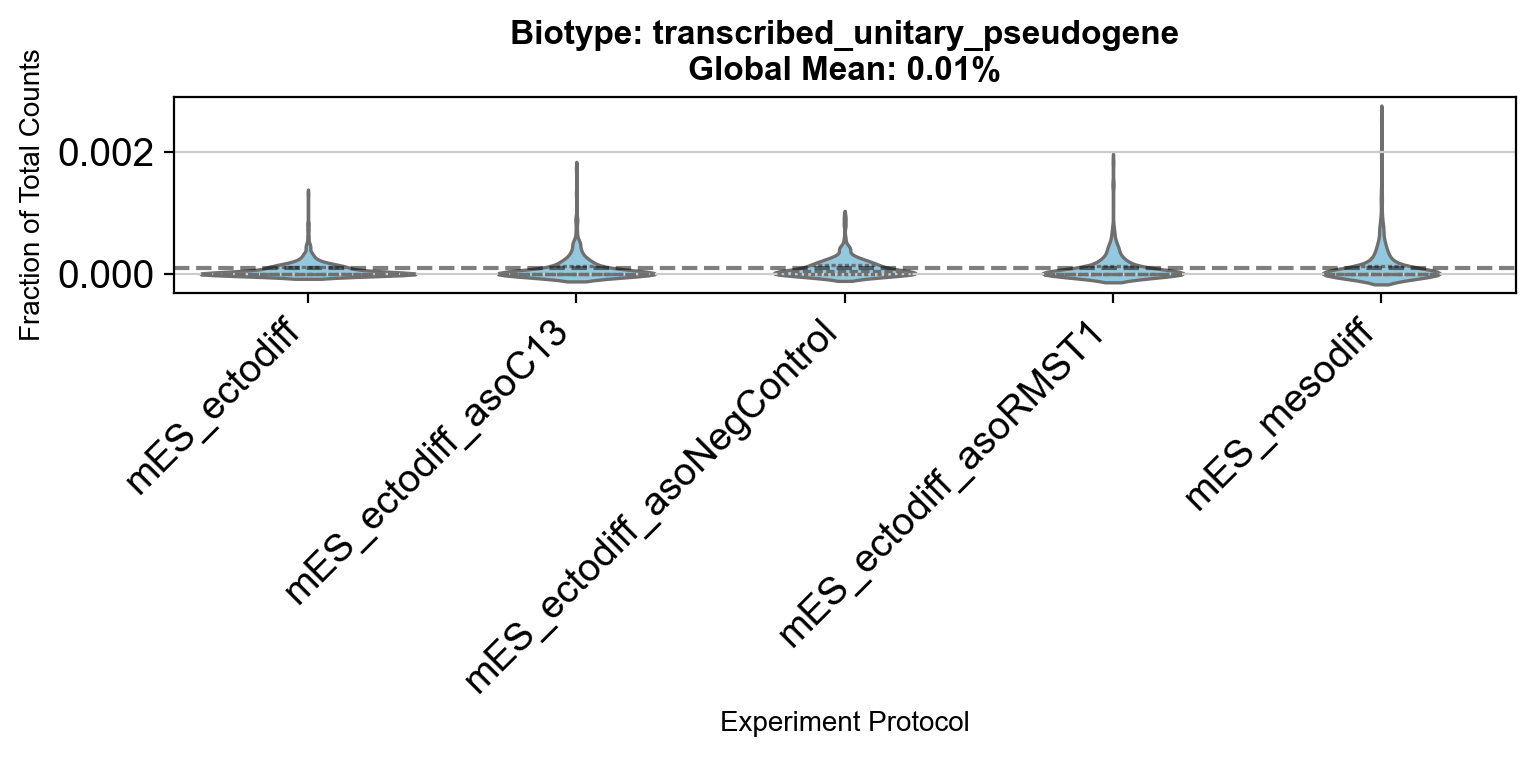

In [13]:
obj = adata_lncRNA
matrix_to_use = obj.raw.X if obj.raw is not None else obj.X

# Helper function to get counts safely
def get_counts_for_mask(matrix, mask):
    mask_array = mask.values if isinstance(mask, pd.Series) else mask
    if issparse(matrix):
        return np.array(matrix[:, mask_array].sum(axis=1)).flatten()
    else:
        return matrix[:, mask_array].sum(axis=1)

# Get total counts per cell
total_mask = np.ones(matrix_to_use.shape[1], dtype=bool)
total_counts = get_counts_for_mask(matrix_to_use, total_mask)
total_counts[total_counts == 0] = 1 # Prevent division by zero

# Dynamically get all unique biotypes present in the metadata
# We drop NaNs to avoid errors if some genes lack annotation
unique_biotypes = obj.var['gene_biotype'].dropna().unique()
print(f"Found {len(unique_biotypes)} unique biotypes in the dataset.")

# Create a dedicated DataFrame for plotting so we don't pollute adata.obs
df_fractions = pd.DataFrame(index=obj.obs.index)
df_fractions['experiment'] = obj.obs['experiment']

# Dictionary to store global means (to sort plots later)
global_means = {}

for bio in unique_biotypes:
    # Create mask dynamically
    bio_mask = obj.var['gene_biotype'] == bio
    
    # Calculate counts and fraction
    bio_counts = get_counts_for_mask(matrix_to_use, bio_mask)
    bio_fraction = bio_counts / total_counts
    
    # Store in our DataFrame
    df_fractions[bio] = bio_fraction
    
    # Store global mean to know if this biotype is actually relevant
    global_means[bio] = bio_fraction.mean()

# Sort biotypes by global abundance (descending)
sorted_biotypes = sorted(global_means, key=global_means.get, reverse=True)

# We plot only biotypes that represent at least 0.01% of the total transcriptome on average.
# This prevents plotting 20 empty graphs for obscure pseudogenes with zero counts.
MIN_FRACTION_THRESHOLD = 0.0001 

for bio in sorted_biotypes:
    if global_means[bio] < MIN_FRACTION_THRESHOLD:
        # Skip biotypes that are basically ghost noise
        continue
        
    plt.figure(figsize=(8, 4))
    
    sns.violinplot(
        data=df_fractions, 
        x='experiment', 
        y=bio, 
        inner='quartile', 
        linewidth=1.2,
        color='skyblue' # You can change this or use a palette
    )
    
    plt.title(f"Biotype: {bio}\nGlobal Mean: {global_means[bio]*100:.2f}%", fontsize=12, fontweight='bold')
    plt.xlabel("Experiment Protocol", fontsize=10)
    plt.ylabel("Fraction of Total Counts", fontsize=10)
    plt.xticks(rotation=45, ha='right')
    
    # Add baseline for reference
    plt.axhline(global_means[bio], color='black', linestyle='--', alpha=0.5, label='Global Median/Mean')
    
    plt.tight_layout()
    plt.show()

Look at means to visualize better global heterogeneities:

--- 3. VISUALIZING GLOBAL MEANS PER PROTOCOL ---


/var/folders/x7/st5qbw1x4w3gr8j8_kcwrvgc0000gn/T/ipykernel_66172/3810934972.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_means = df_fractions.groupby('experiment')[valid_biotypes].mean()


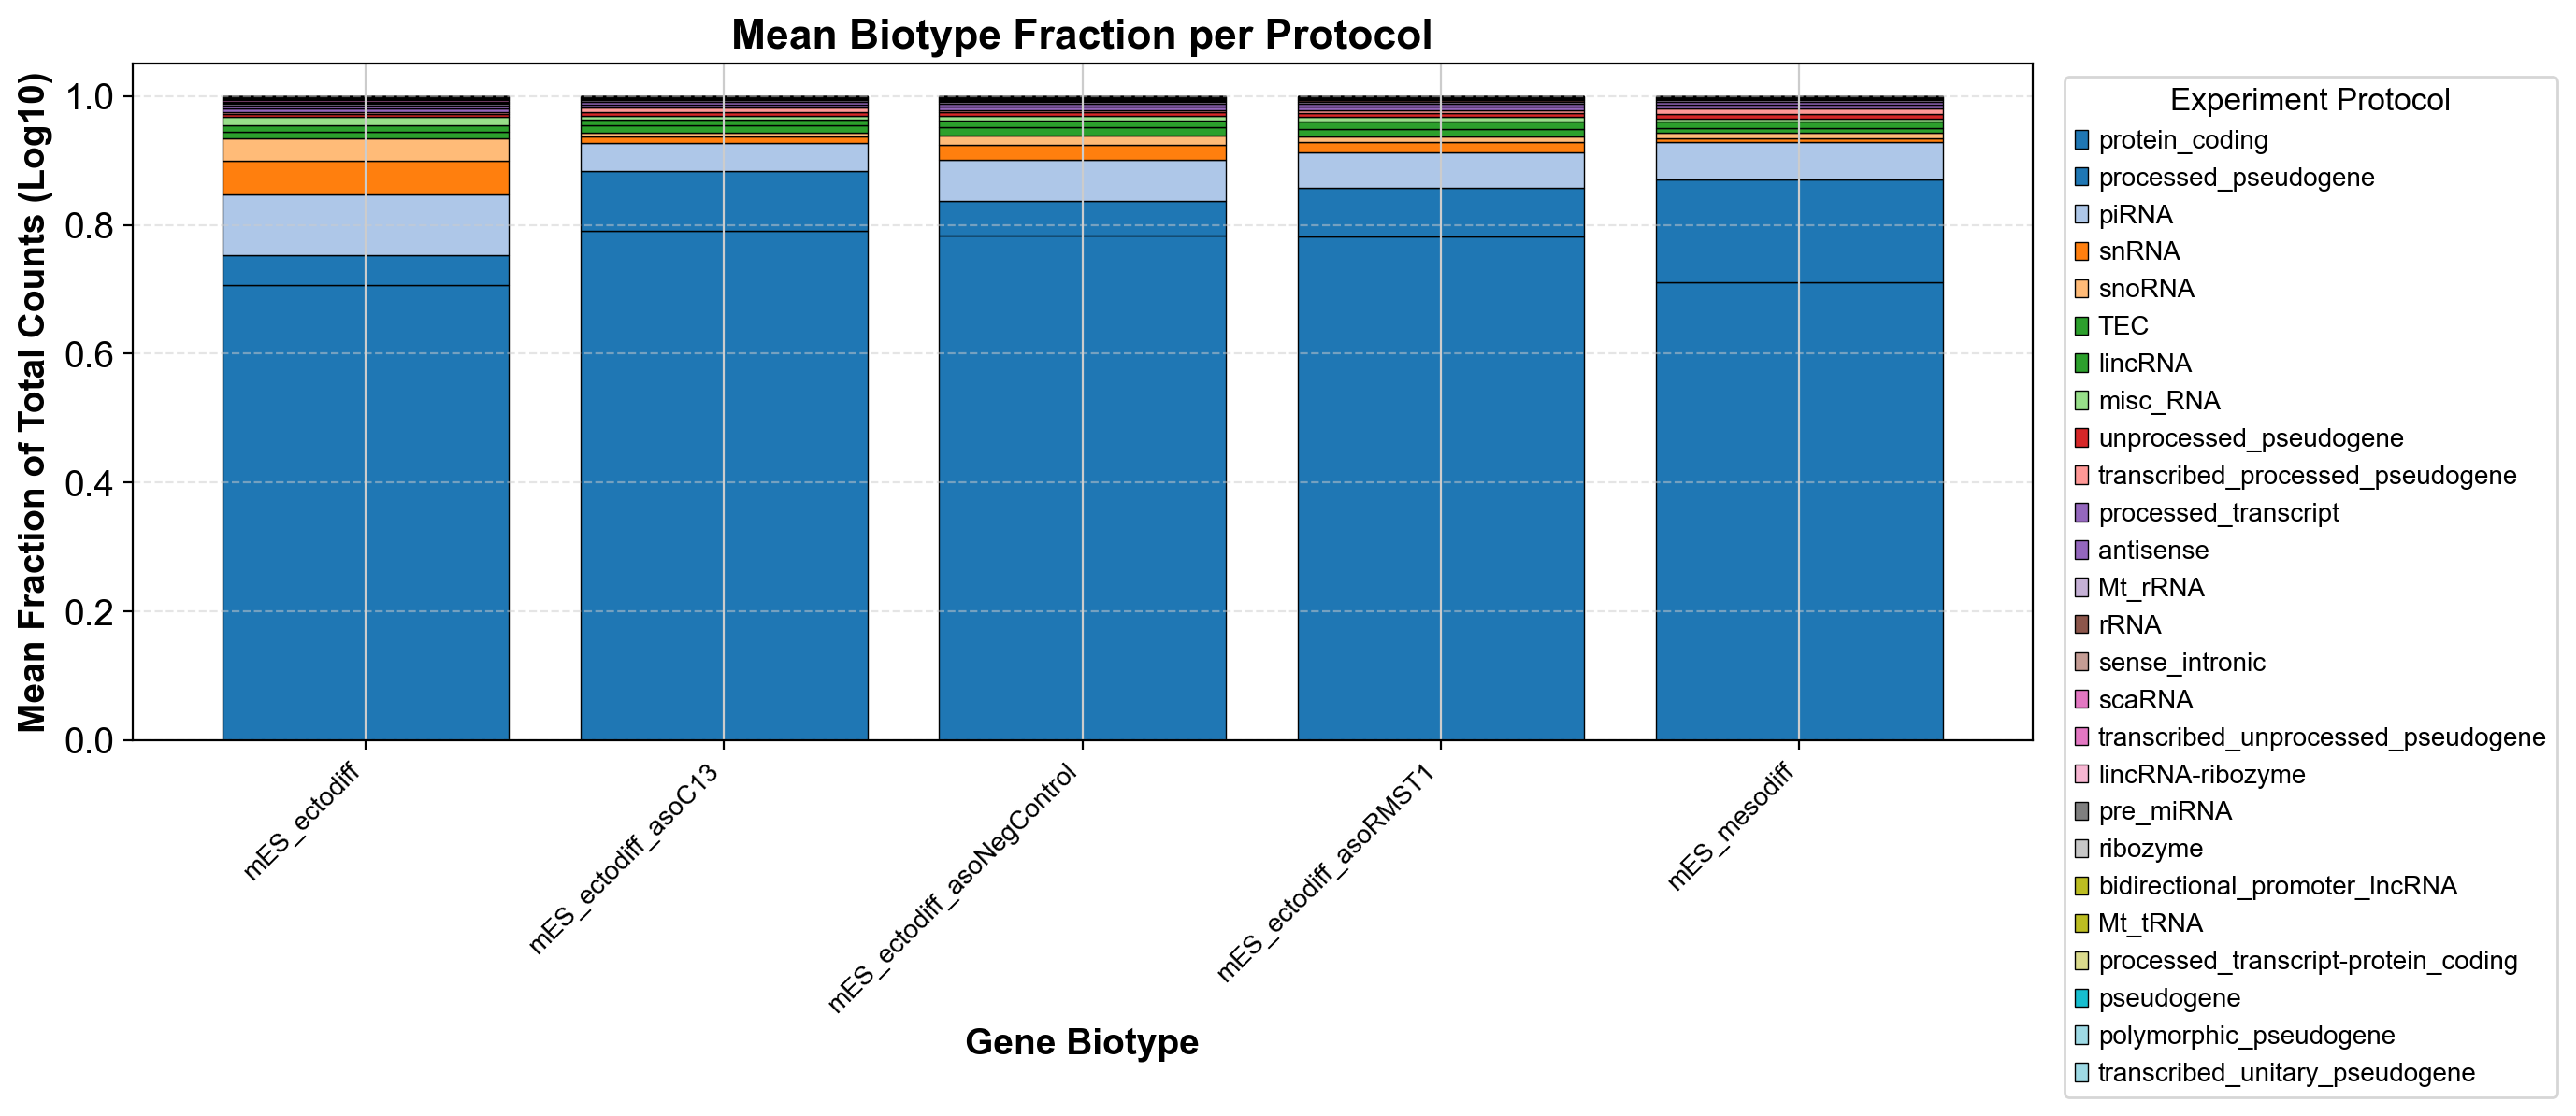

In [ ]:
# --- GLOBAL MEAN BAR CHART (COMPOSITION OVERVIEW) ---

#  Select only the biotypes that passed our noise threshold
valid_biotypes =[bio for bio in sorted_biotypes if global_means[bio] >= MIN_FRACTION_THRESHOLD]

# Group by experiment and calculate the mean for each biotype
# This creates a dataframe where Rows=Experiments, Columns=Biotypes
df_means = df_fractions.groupby('experiment')[valid_biotypes].mean()

# Transpose it so Rows=Biotypes (for the X-axis) and Columns=Experiments (for the bars)
df_plot = df_means

## Grouped Bar Chart
fig, ax = plt.subplots(figsize=(14, 6))

# plot the bars stacked
df_plot.plot(
    kind='bar',
    stacked=True,
    ax=ax, 
    width=0.8,     
    colormap='tab20', 
    edgecolor='black',
    linewidth=0.5,
)

# Aesthetics 
plt.title("Mean Biotype Fraction per Protocol", fontsize=16, fontweight='bold')
plt.xlabel("Gene Biotype", fontsize=14, fontweight='bold')
plt.ylabel("Mean Fraction of Total Counts (Log10)", fontsize=14, fontweight='bold')

# Rotate X labels to avoid overlap
plt.xticks(rotation=45, ha='right', fontsize=10)

# Legend
plt.legend(
    title='Experiment Protocol', 
    title_fontsize='12',
    fontsize='10',
    bbox_to_anchor=(1.01, 1), 
    loc='upper left'
)

# Grid lines
plt.grid(axis='y', which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()